# Clickstream case studies (cleaned)

Other notebooks used:
* `case_studies_support.ipynb` to get the outlinks
* `get_redirects.ipynb` to get redirects for oulinks

In [1]:
from collections import Counter
from collections import defaultdict

import datetime
import glasbey
import gzip
import json
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns
import sqlalchemy as db
import time
import upsetplot

import wikitextparser as wtp
import mwparserfromhell as mwp

import statsmodels.api as sm
from scipy import stats
from statsmodels.formula.api import logit
from wordcloud import WordCloud

In [2]:
def gen_url(rev_id, prev=False, next=False, curr=False):
    """
    Generate a Wikipedia URL based upon a revision ID

    Options: 
    - prev to compare to previous revision
    - next to compare to next revision
    - curr to compare to current revision
    """
    url_ = "https://en.wikipedia.org/wiki/index.php?oldid=" + str(rev_id)
    if prev:
        url_+= "&diff=prev"
    elif curr:
        url_+= "&diff=curr"
    elif next:
        url_+= "&diff=next"

    return url_

In [3]:
def transform_match(match):
    """
    Extract links from templtes with multiple parameters (e.g. {{main}}, {{seealso}}, {{further}}, etc)
    """
    # Get the contents of the template
    content = match.group(1)

    # Split up by pipes, wrap in brackets
    links = [f"[[{link.strip()}]]" for link in content.split('|')]
    
    # Return a single string of wikilinks separated by spaces
    return " ".join(links)

## Import data

In [4]:
# genetics keywords
with open("../metadata/genetics_terms_202601.txt") as f:
    genetics_terms = set(f.read().strip().split("\n"))
f.close()

with open("../metadata/caps_terms.txt") as f:
    caps_terms = set(f.read().strip().split("\n"))
f.close()

In [5]:
pages = [
    "Ashkenazi_Jews",
    "White_people",
    "Black_people"
]

In [7]:
cutoff_date = datetime.date(2026,1,1)

In [8]:
# IDs for Dec 2025
analysis_revision_ids = dict()

analysis_revision_ids["Ashkenazi_Jews"] = 1329564957
analysis_revision_ids["White_people"] = 1330326276
analysis_revision_ids["Black_people"] = 1330488853

In [9]:
for page in pages:
    print(page, gen_url(analysis_revision_ids[page]))

Ashkenazi_Jews https://en.wikipedia.org/wiki/index.php?oldid=1329564957
Palestinians https://en.wikipedia.org/wiki/index.php?oldid=1326057880
White_people https://en.wikipedia.org/wiki/index.php?oldid=1330326276
Black_people https://en.wikipedia.org/wiki/index.php?oldid=1330488853


In [10]:
# Work with the raw data, somehow the reduced data stripped way too much out
clickstream_dir = "../data/datasets/wikipedia/data/clickstream"
clickstream_file = "clickstream-enwiki-2025-12.tsv.gz"

link_map = {
    "external":0,
    "link":1,
    "other":2
}

clickstream_path = os.path.join(clickstream_dir, clickstream_file)

with gzip.open(clickstream_path, 'rt') as f:
    in_data = [t.split("\t") for t in f.read().strip().split("\n")]

In [11]:
# Store the clickstream data for specific pages
clicks = defaultdict(list)
clicks_out = defaultdict(list)

In [12]:
for i in in_data:
    for page in pages:
        if i[2]!="other":
            # There are a handful of links that are not in the text at all but generally "other"
            # This is probably stuff like clicking on a tab or maybe a link in hover text? idk
            if i[0]==page or i[1]==page:
                clicks[page].append(i)
            if i[0]==page:
                clicks_out[page].append(i)

In [15]:
# Import redirect data
# Outlinks for the revisions we are analyzing were determined in case_study_support.ipynb
link_dict = defaultdict(dict)

parent_dir = ".../data/datasets/wikipedia/data/case_studies/2026"

for page in pages:
#for page in ["Ashkenazi_Jews"]:
    #redirect_path = os.path.join(parent_dir, page, page + "_redirects_api_response.txt")
    redirect_path = os.path.join(parent_dir, page, page + "_redirects_api_response.txt")
    with open(redirect_path,"r") as f:
        redirects_raw = f.readlines()

    f.close()
    redirects_json = [json.loads(t.strip()) for t in redirects_raw]
    # The data are stored as a list
    # Each list element is a json object with one or two keys:
    # 1. "normalized", which adjusts for things like capitalization or underscores vs spacing
    # 2. "pages", which contains all of the redirect data
    ## Within "pages", we just have dicts. We can skip any keys with "-" in them (these pages don't exist)
    ## Otherwise within each key, we have "title" (target page) and "redirects"
    ### "redirects" is a list of dicts. Each list element is a dict with "pageid", "ns", and "title"
    ### we want "title"

    for json_item in redirects_json:
        # Redirect API responses are a list of JSON items (dicts)
        for k,v in json_item["pages"].items():
            # The key, value pairs are a page's identifiers (pageid, ns, title) and its redirects (list of dicts)
            if "redirects" in v.keys():
                # If a page has redirects, they are stored as a list of dicts
                for rev in v["redirects"]:
                    # Each list element is a redirect that has a pageid, ns, and title value
                    
                    link_dict[page][rev["title"]] = v["title"]

In [17]:
revision_contents = dict()

revision_contents_dir = ".../data/datasets/wikipedia/data/202601/revision_contents_processed"

for page in pages:
    revision_contents_file = page + ".txt.gz"
    revision_contents_path = os.path.join(revision_contents_dir, revision_contents_file)

    with gzip.open(revision_contents_path) as f:
        article_contents = json.loads(f.read())

    f.close()

    revision_contents[page] = article_contents[str(analysis_revision_ids[page])]
    del article_contents

## Page: Ashkenazi Jews

In [66]:
page_name = "Ashkenazi_Jews"

In [67]:
# Also need to extract the templates' links
# Can do some manual substitutions here
substitution_dir = ".../data/datasets/wikipedia/data/case_studies/2026/templates"

with open(os.path.join(substitution_dir, "Template:Jews_and_Judaism_sidebar.txt")) as f:
    template_jews_and_judaism_sidebar = f.read().strip()

with open(os.path.join(substitution_dir, "Template:Demographics_of_Israel.txt")) as f:
    template_ethnic_groups_in_israel = f.read().strip()

with open(os.path.join(substitution_dir, "Template:Jews_and_Judaism.txt")) as f:
    template_jews_and_judaism = f.read().strip()

with open(os.path.join(substitution_dir, "Template:Europe_topic.txt")) as f:
    template_europe_topic = f.read().strip()

In [68]:
# The Europe topic template is complicated so I have a list of links for it
with open(os.path.join(".../data/datasets/wikipedia/data/case_studies/2026/Ashkenazi_Jews/Ashkenazi_Jews_history_pages.txt")) as f:
    template_europe_topic_links = "\n".join(["[["+l+"]]" for l in f.read().strip().split("\n")])

In [69]:
# Copy text
revision_contents_substituted = revision_contents["Ashkenazi_Jews"]

# Navigation templates
revision_contents_substituted = revision_contents_substituted.replace("{{Jews and Judaism sidebar",template_jews_and_judaism_sidebar)
revision_contents_substituted = revision_contents_substituted.replace("{{Ethnic groups in Israel}}",template_ethnic_groups_in_israel)
revision_contents_substituted = revision_contents_substituted.replace("{{Jews and Judaism}}",template_jews_and_judaism)

# Other templates
revision_contents_substituted = re.sub(r'\{\{flag\|(.*?)\}\}',r'[[\1]]', revision_contents_substituted, flags=re.IGNORECASE) # {{flag}} template
revision_contents_substituted = re.sub(r'\{\{main\|(.*?)\}\}',r'[[\1]]', revision_contents_substituted, flags=re.IGNORECASE) # {{main}} template
revision_contents_substituted = re.sub(r'\{\{see also\|(.*?)\}\}',r'[[\1]]', revision_contents_substituted, flags=re.IGNORECASE) # {{see also}} template
revision_contents_substituted = re.sub(r'{{Redirect\|Ashkenazi\|the surname\|(.*?)\}\}',r'[[\1]]', revision_contents_substituted, flags=re.IGNORECASE) # {{redirect}} template

# Get rid of documentation templates
revision_contents_substituted = re.sub(r'<noinclude>.*?<\/noinclude>','',revision_contents_substituted)

In [70]:
parsed = wtp.parse(revision_contents_substituted)

In [71]:
for section in parsed.sections:
    print(section)
    print()

{{Short description|Jewish diaspora of Central Europe}} 
[[Ashkenazi (surname)]]
{{Pp|small=yes}}
{{Use dmy dates|date=December 2022}}
{{Infobox ethnic group
| group            = Ashkenazi Jews
| native_name      = {{Script/Hebrew|אַשְׁכְּנַזִּים|}} ({{lang|he-Latn|Ashkenazim}})
| native_name_lang = he
| image            = Maurycy Gottlieb - Jews Praying in the Synagogue on Yom Kippur.jpg
| image_caption    = ''[[Jews Praying in the Synagogue on Yom Kippur]]'' (1878)
| population       = 10<ref name="Ashkenazi-jews-hugr">{{cite web|title=Ashkenazi Jews |url=http://hugr.huji.ac.il/AshkenaziJews.aspx |publisher=[[Hebrew University of Jerusalem]] |access-date=29 October 2013 |archive-url=https://web.archive.org/web/20131020004618/http://hugr.huji.ac.il/AshkenaziJews.aspx |archive-date=20 October 2013}}</ref>–11.2<ref name="Jhu.edu">{{cite news |url=http://www.jhu.edu/~gazette/julsep97/sep0897/briefs.html |title=First genetic mutation for colorectal cancer identified in Ashkenazi Jews |pub

In [72]:
# Set up the dict of views for each link
click_counts = dict()

for link in clicks_out["Ashkenazi_Jews"]:
    click_counts[link[1]] = int(link[3])

In [73]:
# Sort by frequency
{k: v for k, v in sorted(click_counts.items(), key=lambda item: item[1], reverse=True)}

{'Jewish_diaspora': 5232,
 'Sephardic_Jews': 3107,
 'Rhineland': 2923,
 'Casimir_III_the_Great': 2875,
 'Yiddish': 2674,
 'List_of_East_European_Jews': 2511,
 'Jewish_ethnic_divisions': 2198,
 'Mizrahi_Jews': 1859,
 'Persecution_of_Jews_during_the_Black_Death': 1698,
 'Israel': 1439,
 'Jews_Praying_in_the_Synagogue_on_Yom_Kippur': 1092,
 'Holy_Roman_Empire': 1041,
 'Jewish_atheism': 1027,
 'History_of_the_Jews_in_Poland': 983,
 'The_Holocaust': 961,
 'Federation_of_Jewish_Communities_of_Russia': 884,
 'Jewish_population_by_country': 883,
 'Crusades': 806,
 'Ashkenaz': 734,
 'Judaism': 501,
 'Jewish_secularism': 499,
 'Haskalah': 496,
 'Early_Middle_Ages': 481,
 'Cimmerians': 464,
 'Saadia_Marciano': 462,
 'Samaritans': 432,
 'Genetic_studies_of_Jews': 430,
 'Israelites': 430,
 'Racism_in_Israel': 375,
 'Yellow_badge': 371,
 'Ashkenazi_Hebrew': 359,
 'Khazars': 353,
 'Middle_High_German': 303,
 'Endogamy': 298,
 'Aramaic': 273,
 'Sergio_Della_Pergola': 268,
 'Revival_of_the_Hebrew_langu

In [74]:
## Assign sections to links
#section_links = defaultdict(set)
#top_section_counter = 0 # Intro and top-level
#sub_section_counter = 0 # Sub-sections (actually ignoring this for now
#section_counter = 0 # 
#
#subsection_title = ""
#
#top_section_list = []
#overall_section_list = []
#link_list = []
#trans_list = []
#view_list = []
#first_appearance = []
#
#link_dict_keys = [k.lower().replace(" ","_") for k in link_dict[page_name].keys()]
#
#link_dict_lower = dict()
#for k in link_dict[page_name].keys():
#    link_dict_lower[k.lower().replace(" ","_")] = link_dict[page_name][k]
#
#
#for section in parsed.sections:
#    for link in section.wikilinks:
#        relative_section = str(top_section_counter) + "." + str(sub_section_counter)
#        if section.title is None:
#            section_title = "Introduction"
#        else:
#            section_title = section.title
#        
#        target = link.target
#        
#        print("Overall:", section_counter, "", top_section_counter, section_title, target.replace(" ","_"))
#
#        section_links[top_section_counter].add(target.replace(" ","_").lower())
#
#
#        # Only keep links the first times they appear
#        if target not in link_list:
#            first_appearance.append(True)
#        else:
#            first_appearance.append(False)
#        
#        top_section_list.append(top_section_counter)
#        overall_section_list.append(section_counter)
#        link_list.append(target)
#
#        # Translated redirects
#        if target.lower().replace(" ","_") in link_dict_lower:
#            trans_list.append(link_dict_lower[target.lower().replace(" ","_")])
#        else:
#            trans_list.append(target)
#    
#    if section.level==2:
#        top_section_counter+= 1
#        sub_section_counter = 0
#    #if section.level==2:
#        # Only look at main sections?
#    section_counter+= 1
#        

In [75]:
# Rewrite to make sure that the links are being translated correctly
# Assign sections to links
section_links = defaultdict(set)
top_section_counter = 0 # Intro and top-level
sub_section_counter = 0 # Sub-sections (actually ignoring this for now
section_counter = 0 # 

subsection_title = ""

top_section_list = []
overall_section_list = []
link_list = [] # List of all links
trans_list = [] # Translated links
view_list = []
first_appearance = []

link_dict_keys = [k.lower().replace(" ","_") for k in link_dict[page_name].keys()]

link_dict_lower = dict()
for k in link_dict[page_name].keys():
    link_dict_lower[k.lower().replace(" ","_")] = link_dict[page_name][k]


for section in parsed.sections:
    if section.level==2:
        top_section_counter+= 1
        sub_section_counter = 0
    section_counter+= 1
    
    for link in section.wikilinks:
        relative_section = str(top_section_counter) + "." + str(sub_section_counter)
        if section.title is None:
            section_title = "Introduction"
        else:
            section_title = section.title

        # Get the target link and check if it's in our dictionary of redirects
        target = link.target
        target_lower = target.replace(" ","_").lower()

        print("Overall:", section_counter, "", top_section_counter, section_title, target.replace(" ","_"))

        section_links[top_section_counter].add(target.replace(" ","_").lower())

        # If the link is in the dictionary of redirects, translate the link
        # Otherwise, assume that the link is direct
        # e.g. "Letter_to_Darius_III" goes to "Alexander_the_Great" and is in the dictionary (redirect)
        # but "Alexander_the_Great" is not (direct link)
        if target_lower in link_dict_lower.keys():
            trans_link = link_dict_lower[target_lower]
        else:
            trans_link = target

        trans_list.append(trans_link)
        
        # Check if this is the first time a link has appeared in the text
        if trans_link not in link_list:
            first_appearance.append(True)
        else:
            first_appearance.append(False)

        top_section_list.append(top_section_counter)
        overall_section_list.append(section_counter)
        link_list.append(target)

Overall: 1  0 Introduction Ashkenazi_(surname)
Overall: 1  0 Introduction Jews_Praying_in_the_Synagogue_on_Yom_Kippur
Overall: 1  0 Introduction Hebrew_University_of_Jerusalem
Overall: 1  0 Introduction United_States
Overall: 1  0 Introduction Israel_Medical_Association_Journal
Overall: 1  0 Introduction Israel
Overall: 1  0 Introduction Russia
Overall: 1  0 Introduction Federation_of_Jewish_Communities_of_Russia
Overall: 1  0 Introduction Argentina
Overall: 1  0 Introduction United_Kingdom
Overall: 1  0 Introduction Canada
Overall: 1  0 Introduction France
Overall: 1  0 Introduction Germany
Overall: 1  0 Introduction Ukraine
Overall: 1  0 Introduction Australia
Overall: 1  0 Introduction South_Africa
Overall: 1  0 Introduction Belarus
Overall: 1  0 Introduction Brazil
Overall: 1  0 Introduction Hungary
Overall: 1  0 Introduction Chile
Overall: 1  0 Introduction Belgium
Overall: 1  0 Introduction Netherlands
Overall: 1  0 Introduction Moldova
Overall: 1  0 Introduction Italy
Overall: 1

In [77]:
len(trans_list)

1787

In [78]:
df_links = pd.DataFrame(
    {
        "top_level_section":top_section_list,
        "overall_section":overall_section_list,
        "link":link_list,
        "link_target":trans_list,
        "link_target_2":[t.replace(" ","_") for t in trans_list]
    }
)

In [79]:
df_links

,top_level_section,overall_section,link,link_target,link_target_2
0,0,1,Ashkenazi (surname),Ashkenazi (surname),Ashkenazi_(surname)
1,0,1,Jews Praying in the Synagogue on Yom Kippur,Jews Praying in the Synagogue on Yom Kippur,Jews_Praying_in_the_Synagogue_on_Yom_Kippur
2,0,1,Hebrew University of Jerusalem,Hebrew University of Jerusalem,Hebrew_University_of_Jerusalem
3,0,1,United States,United States,United_States
4,0,1,Israel Medical Association Journal,Israel Medical Association Journal,Israel_Medical_Association_Journal
...,...,...,...,...,...
1782,11,37,Category:Ashkenazi Jews,Category:Ashkenazi Jews,Category:Ashkenazi_Jews
1783,11,37,Category:Ethnic groups in Israel,Category:Ethnic groups in Israel,Category:Ethnic_groups_in_Israel
1784,11,37,Category:Ethnic groups in Russia,Category:Ethnic groups in Russia,Category:Ethnic_groups_in_Russia
1785,11,37,Category:Jewish ethnic groups,Category:Jewish ethnic groups,Category:Jewish_ethnic_groups


In [81]:
df_clicks = pd.DataFrame(
    {
        "page_name":[l[1] for l in clicks_out[page_name]],
        "clicks":[int(l[3]) for l in clicks_out[page_name]]
    }
)

In [82]:
df_links

,top_level_section,overall_section,link,link_target,link_target_2
0,0,1,Ashkenazi (surname),Ashkenazi (surname),Ashkenazi_(surname)
1,0,1,Jews Praying in the Synagogue on Yom Kippur,Jews Praying in the Synagogue on Yom Kippur,Jews_Praying_in_the_Synagogue_on_Yom_Kippur
2,0,1,Hebrew University of Jerusalem,Hebrew University of Jerusalem,Hebrew_University_of_Jerusalem
3,0,1,United States,United States,United_States
4,0,1,Israel Medical Association Journal,Israel Medical Association Journal,Israel_Medical_Association_Journal
...,...,...,...,...,...
1782,11,37,Category:Ashkenazi Jews,Category:Ashkenazi Jews,Category:Ashkenazi_Jews
1783,11,37,Category:Ethnic groups in Israel,Category:Ethnic groups in Israel,Category:Ethnic_groups_in_Israel
1784,11,37,Category:Ethnic groups in Russia,Category:Ethnic groups in Russia,Category:Ethnic_groups_in_Russia
1785,11,37,Category:Jewish ethnic groups,Category:Jewish ethnic groups,Category:Jewish_ethnic_groups


In [83]:
df_links_clicks = pd.merge(
    left = df_links,
    right = df_clicks,
    how = "left",
    left_on = "link_target_2",
    right_on = "page_name"
)

In [84]:
df_links_clicks[df_links_clicks["link_target_2"]=="Sephardic_Jews"]

,top_level_section,overall_section,link,link_target,link_target_2,page_name,clicks
49,0,1,Sephardi Jews,Sephardic Jews,Sephardic_Jews,Sephardic_Jews,3107.0
172,0,1,Sephardic Jews,Sephardic Jews,Sephardic_Jews,Sephardic_Jews,3107.0
338,0,1,Sephardic Jews,Sephardic Jews,Sephardic_Jews,Sephardic_Jews,3107.0
643,2,3,Sephardim,Sephardic Jews,Sephardic_Jews,Sephardic_Jews,3107.0
702,2,3,Sephardi Jews,Sephardic Jews,Sephardic_Jews,Sephardic_Jews,3107.0
740,2,3,Sephardi Jews,Sephardic Jews,Sephardic_Jews,Sephardic_Jews,3107.0
824,2,7,Sephardim,Sephardic Jews,Sephardic_Jews,Sephardic_Jews,3107.0
883,2,8,Sephardi Jews,Sephardic Jews,Sephardic_Jews,Sephardic_Jews,3107.0
921,2,9,Sephardi Jews,Sephardic Jews,Sephardic_Jews,Sephardic_Jews,3107.0
948,2,10,Sephardi Jews,Sephardic Jews,Sephardic_Jews,Sephardic_Jews,3107.0


### Excluding navigation boxes and templates

Remove navigation templates and references. This strips out a lot of uninformative links that are present in citation tags and while *technically* inside of a section are actually only available in the "References" section.

Run this after running the previous chunk (it will overwrite but only takes a few seconds to run anyway)

In [196]:
# Copy text
revision_contents_substituted = revision_contents[page_name]

# Navigation templates
revision_contents_substituted = revision_contents_substituted.replace("{{Jews and Judaism sidebar|communities}}","")
revision_contents_substituted = revision_contents_substituted.replace("{{Demographics of Israel}}","")
revision_contents_substituted = revision_contents_substituted.replace("{{Jews and Judaism}}","")

# Other templates
revision_contents_substituted = re.sub(r'\{\{flag\|(.*?)\}\}',r'[[\1]]', revision_contents_substituted, flags=re.IGNORECASE) # {{flag}} template
revision_contents_substituted = re.sub(r'\{\{main\|(.*?)\}\}',r'[[\1]]', revision_contents_substituted, flags=re.IGNORECASE) # {{main}} template
revision_contents_substituted = re.sub(r'\{\{see also\|(.*?)\}\}',r'[[\1]]', revision_contents_substituted, flags=re.IGNORECASE) # {{see also}} template
revision_contents_substituted = re.sub(r'{{Redirect\|Ashkenazi\|the surname\|(.*?)\}\}',r'[[\1]]', revision_contents_substituted, flags=re.IGNORECASE) # {{redirect}} template

# Get rid of documentation templates
revision_contents_substituted = re.sub(r'<noinclude>.*?<\/noinclude>','',revision_contents_substituted)

In [199]:
parsed = wtp.parse(revision_contents_substituted)

In [198]:
for tag in parsed.get_tags():
    revision_contents_substituted = revision_contents_substituted.replace(tag.string,"")

In [200]:
for section in parsed.sections:
    #print(section)
    print("*****")
    print(section.title)
    print("*****")
    for wl in section.wikilinks:
        print(wl, wl.target.split("#")[0])

*****
None
*****
[[Flag of Palestine]] Flag of Palestine
[[File:Map of the Palestinian diaspora in the World.svg||center|frameless|260px]] File:Map of the Palestinian diaspora in the World.svg
[[Palestine]] Palestine
[[West Bank]] West Bank
[[Gaza Strip]] Gaza Strip
[[Jordan]] Jordan
[[Israel]] Israel
[[Syria]] Syria
[[Chile]] Chile
[[Saudi Arabia]] Saudi Arabia
[[Qatar]] Qatar
[[United States]] United States
[[Germany]] Germany
[[United Arab Emirates]] United Arab Emirates
[[Lebanon]] Lebanon
[[Egypt]] Egypt
[[Kuwait]] Kuwait
[[Honduras]] Honduras
[[Libya]] Libya
[[El Salvador]] El Salvador
[[Iraq]] Iraq
[[Brazil]] Brazil
[[Canada]] Canada
[[Yemen]] Yemen
[[Turkey]] Turkey
[[United Kingdom]] United Kingdom
[[Peru]] Peru
[[Mexico]] Mexico
[[Colombia]] Colombia
[[Netherlands]] Netherlands
[[Australia]] Australia
[[White Australia Policy]] White Australia Policy
[[Arab Australians]] Arab Australians
[[Sweden]] Sweden
[[Algeria]] Algeria
[[Arabic]] Arabic
[[Palestinian Arabic]] Palestinia

In [201]:
## Assign sections to links
#section_links = defaultdict(set)
#top_section_counter = 0 # Intro and top-level
#sub_section_counter = 0 # Sub-sections (actually ignoring this for now
#section_counter = 0 # 
#
#section_titles = []
#top_section_list = []
#overall_section_list = []
#link_list = []
#trans_list = []
#view_list = []
#first_appearance = []
#
#prev_title = ""
#
## Set up dictionaries to translate redirects to consistent article targets
##aj_link_dict_keys = [k.lower().replace(" ","_") for k in aj_link_dict.keys()]
#link_dict_keys = [k.lower().replace(" ","_") for k in link_dict.keys()]
#
#link_dict_lower = dict()
#for k in link_dict.keys():
#    link_dict_lower[k.lower().replace(" ","_")] = link_dict[k]
#
#for section in parsed.sections:
#
#    # Get the section title
#    if section.title is None:
#        section_title = "Introduction"
#    else:
#        section_title = section.title
#
#    # If we are at a top-level section, increment the counter
#    if section.level==2:
#        if section_title!="Introduction":
#            top_section_counter+=1
#            sub_section_counter= 0 # not implemented yet
#
#    # Overall section counter
#    section_counter+=1
#    
#    for link in section.wikilinks:
#        #relative_section = str(top_section_counter) + "." + str(sub_section_counter) # not implemented
#        
#        target = link.target.split("#")[0]
#        
#        print("Overall:", section_counter, "", top_section_counter, section_title, target.replace(" ","_"))
#
#        section_links[top_section_counter].add(target.replace(" ","_").lower())
#        section_titles.append(section_title)
#        
#        top_section_list.append(top_section_counter)
#        overall_section_list.append(section_counter)
#        link_list.append(target)
#
#        # Translated redirects
#        if target.lower().replace(" ","_") in link_dict_lower:
#            trans_link = link_dict_lower[target.lower().replace(" ","_")]
#        else:
#            trans_link = target
#
#        # Flag if this is the first time a link has appeared
#        # We use the translated link (e.g. Sephardi goes to Sephardic_Jews)
#        if trans_link in trans_list:
#            first_appearance.append(False)
#        else:
#            first_appearance.append(True)
#
#        # Append to the list of translated links
#        trans_list.append(trans_link)
#        

In [223]:
# Rewrite to make sure that the links are being translated correctly
# Assign sections to links
section_links = defaultdict(set)
top_section_counter = 0 # Intro and top-level
sub_section_counter = 0 # Sub-sections (actually ignoring this for now)
section_counter = 0 # 

subsection_title = ""

section_titles = []
top_section_list = []
overall_section_list = []
link_list = [] # List of all links
trans_list = [] # Translated links
view_list = []
first_appearance = []

link_dict_keys = [k.lower().replace(" ","_") for k in link_dict[page_name].keys()]

link_dict_lower = dict()
for k in link_dict[page_name].keys():
    link_dict_lower[k.lower().replace(" ","_")] = link_dict[page_name][k]


for section in parsed.sections:
    if section.level==2:
        top_section_counter+= 1
        sub_section_counter = 0
    section_counter+= 1
    
    for link in section.wikilinks:
        relative_section = str(top_section_counter) + "." + str(sub_section_counter)
        if section.title is None:
            section_title = "Introduction"
        else:
            section_title = section.title

        # Get the target link and check if it's in our dictionary of redirects
        target = link.target
        #target = link.target.split("#")[0]
        target_lower = target.replace(" ","_").lower()

        print("Overall:", section_counter, "", top_section_counter, section_title, target.replace(" ","_"))

        section_titles.append(section_title)
        section_links[top_section_counter].add(target.replace(" ","_").lower())

        # If the link is in the dictionary of redirects, translate the link
        # Otherwise, assume that the link is direct
        # e.g. "Letter_to_Darius_III" goes to "Alexander_the_Great" and is in the dictionary (redirect)
        # but "Alexander_the_Great" is not (direct link)
        if target_lower in link_dict_lower.keys():
            trans_link = link_dict_lower[target_lower]
        else:
            trans_link = target

        trans_list.append(trans_link)
        
        # Check if this is the first time a link has appeared in the text
        if trans_link not in link_list:
            first_appearance.append(True)
        else:
            first_appearance.append(False)

        top_section_list.append(top_section_counter)
        overall_section_list.append(section_counter)
        
        #link_list.append(target)
        link_list.append(trans_link)

Overall: 1  0 Introduction Flag_of_Palestine
Overall: 1  0 Introduction File:Map_of_the_Palestinian_diaspora_in_the_World.svg
Overall: 1  0 Introduction Palestine
Overall: 1  0 Introduction West_Bank
Overall: 1  0 Introduction Gaza_Strip
Overall: 1  0 Introduction Jordan
Overall: 1  0 Introduction Israel
Overall: 1  0 Introduction Syria
Overall: 1  0 Introduction Chile
Overall: 1  0 Introduction Saudi_Arabia
Overall: 1  0 Introduction Qatar
Overall: 1  0 Introduction United_States
Overall: 1  0 Introduction Germany
Overall: 1  0 Introduction United_Arab_Emirates
Overall: 1  0 Introduction Lebanon
Overall: 1  0 Introduction Egypt
Overall: 1  0 Introduction Kuwait
Overall: 1  0 Introduction Honduras
Overall: 1  0 Introduction Libya
Overall: 1  0 Introduction El_Salvador
Overall: 1  0 Introduction Iraq
Overall: 1  0 Introduction Brazil
Overall: 1  0 Introduction Canada
Overall: 1  0 Introduction Yemen
Overall: 1  0 Introduction Turkey
Overall: 1  0 Introduction United_Kingdom
Overall: 1  

In [206]:
df_links = pd.DataFrame(
    {
        "section_title":section_titles,
        "top_level_section":top_section_list,
        "overall_section":overall_section_list,
        "link":link_list,
        "link_target":trans_list,
        "link_target_2":[t.replace(" ","_") for t in trans_list],
        "first_appearance":first_appearance
    }
)

In [207]:
df_links_clicks = pd.merge(
    left = df_links,
    right = df_clicks,
    how = "left",
    left_on = "link_target_2",
    right_on = "page_name"
)

In [208]:
df_links_clicks = df_links_clicks.fillna(0)

In [209]:
df_links_clicks

,section_title,top_level_section,overall_section,link,link_target,link_target_2,first_appearance,page_name,clicks
0,Introduction,0,1,Flag of Palestine,Flag of Palestine,Flag_of_Palestine,True,Flag_of_Palestine,183.0
1,Introduction,0,1,File:Map of the Palestinian diaspora in the Wo...,File:Map of the Palestinian diaspora in the Wo...,File:Map_of_the_Palestinian_diaspora_in_the_Wo...,True,0,0.0
2,Introduction,0,1,Palestine,Palestine,Palestine,True,Palestine,720.0
3,Introduction,0,1,West Bank,West Bank,West_Bank,True,West_Bank,372.0
4,Introduction,0,1,Gaza Strip,Gaza Strip,Gaza_Strip,True,Gaza_Strip,361.0
...,...,...,...,...,...,...,...,...,...
1164,External links,11,33,Category:Arab citizens of Israel,Category:Arab citizens of Israel,Category:Arab_citizens_of_Israel,True,0,0.0
1165,External links,11,33,Category:Arab people,Category:Arab people,Category:Arab_people,True,0,0.0
1166,External links,11,33,Category:Stateless nationalism in Asia,Category:Stateless nationalism in Asia,Category:Stateless_nationalism_in_Asia,True,0,0.0
1167,External links,11,33,Category:Stateless people,Category:Stateless people,Category:Stateless_people,True,0,0.0


In [210]:
link_position = 0
for v in df_links_clicks.values:
    print(link_position, v)
    link_position+= 1

0 ['Introduction' 0 1 'Flag of Palestine' 'Flag of Palestine'
 'Flag_of_Palestine' True 'Flag_of_Palestine' 183.0]
1 ['Introduction' 0 1
 'File:Map of the Palestinian diaspora in the World.svg'
 'File:Map of the Palestinian diaspora in the World.svg'
 'File:Map_of_the_Palestinian_diaspora_in_the_World.svg' True 0 0.0]
2 ['Introduction' 0 1 'Palestine' 'Palestine' 'Palestine' True 'Palestine'
 720.0]
3 ['Introduction' 0 1 'West Bank' 'West Bank' 'West_Bank' True 'West_Bank'
 372.0]
4 ['Introduction' 0 1 'Gaza Strip' 'Gaza Strip' 'Gaza_Strip' True
 'Gaza_Strip' 361.0]
5 ['Introduction' 0 1 'Jordan' 'Jordan' 'Jordan' True 'Jordan' 261.0]
6 ['Introduction' 0 1 'Israel' 'Israel' 'Israel' True 'Israel' 383.0]
7 ['Introduction' 0 1 'Syria' 'Syria' 'Syria' True 'Syria' 76.0]
8 ['Introduction' 0 1 'Chile' 'Chile' 'Chile' True 'Chile' 188.0]
9 ['Introduction' 0 1 'Saudi Arabia' 'Saudi Arabia' 'Saudi_Arabia' True
 'Saudi_Arabia' 36.0]
10 ['Introduction' 0 1 'Qatar' 'Qatar' 'Qatar' True 'Qatar' 35

In [211]:
#df_links_clicks["log_clicks"] = df_links_clicks[]
df_links_clicks["log_clicks"] = np.where(df_links_clicks["clicks"] > 0, np.log(df_links_clicks["clicks"]), df_links_clicks["clicks"])
#df_links_clicks["log_clicks"] = np.where(df_links_clicks["log_clicks"] == 1, np.log(df_links_clicks["clicks"]), df_links_clicks["clicks"])

/oscar/home/adiazpap/wikistudy/wiki_venv_3_13_5/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [212]:
range(0, len(df_links_clicks))

range(0, 1169)

In [213]:
df_links_clicks.index

RangeIndex(start=0, stop=1169, step=1)

In [214]:
# delineate where the sections are (vertical lines)
cur_section = 0
cur_subsection = 0
idx_section = list()
idx_subsection = list()
counter = 0

for v in df_links_clicks.values:
    if v[1]!=cur_section:
        idx_section.append(counter)
        cur_section+=1
    if v[2]!=cur_subsection:
        idx_subsection.append(counter)
        cur_subsection+=1

    counter+= 1

In [215]:
idx_section

[99, 163, 215, 252, 381, 566, 723, 823, 1127, 1129, 1163]

In [216]:
# identify links that have genetics terms
idx_keywords = list()
for v in df_links_clicks.values:
    if any(k.lower() in v[3].lower() for k in genetics_terms) or any(k.lower() in v[4].lower() for k in genetics_terms):
        idx_keywords.append(True)
    elif "DNA" in v[3] or "DNA" in v[4]:
        idx_keywords.append(True)
    else:
        idx_keywords.append(False)

In [217]:
idx_keywords

[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,


In [218]:
for v in df_links_clicks[df_links_clicks["first_appearance"]].values:
    print(v)

['Introduction' 0 1 'Flag of Palestine' 'Flag of Palestine'
 'Flag_of_Palestine' True 'Flag_of_Palestine' 183.0 5.209486152841421]
['Introduction' 0 1
 'File:Map of the Palestinian diaspora in the World.svg'
 'File:Map of the Palestinian diaspora in the World.svg'
 'File:Map_of_the_Palestinian_diaspora_in_the_World.svg' True 0 0.0 0.0]
['Introduction' 0 1 'Palestine' 'Palestine' 'Palestine' True 'Palestine'
 720.0 6.579251212010101]
['Introduction' 0 1 'West Bank' 'West Bank' 'West_Bank' True 'West_Bank'
 372.0 5.918893854273146]
['Introduction' 0 1 'Gaza Strip' 'Gaza Strip' 'Gaza_Strip' True
 'Gaza_Strip' 361.0 5.8888779583328805]
['Introduction' 0 1 'Jordan' 'Jordan' 'Jordan' True 'Jordan' 261.0
 5.564520407322694]
['Introduction' 0 1 'Israel' 'Israel' 'Israel' True 'Israel' 383.0
 5.948034989180646]
['Introduction' 0 1 'Syria' 'Syria' 'Syria' True 'Syria' 76.0
 4.330733340286331]
['Introduction' 0 1 'Chile' 'Chile' 'Chile' True 'Chile' 188.0
 5.236441962829949]
['Introduction' 0 1 '

Text(0.5, 1.0, 'Link clicks in Ashkenazi Jews page (December 2025)')

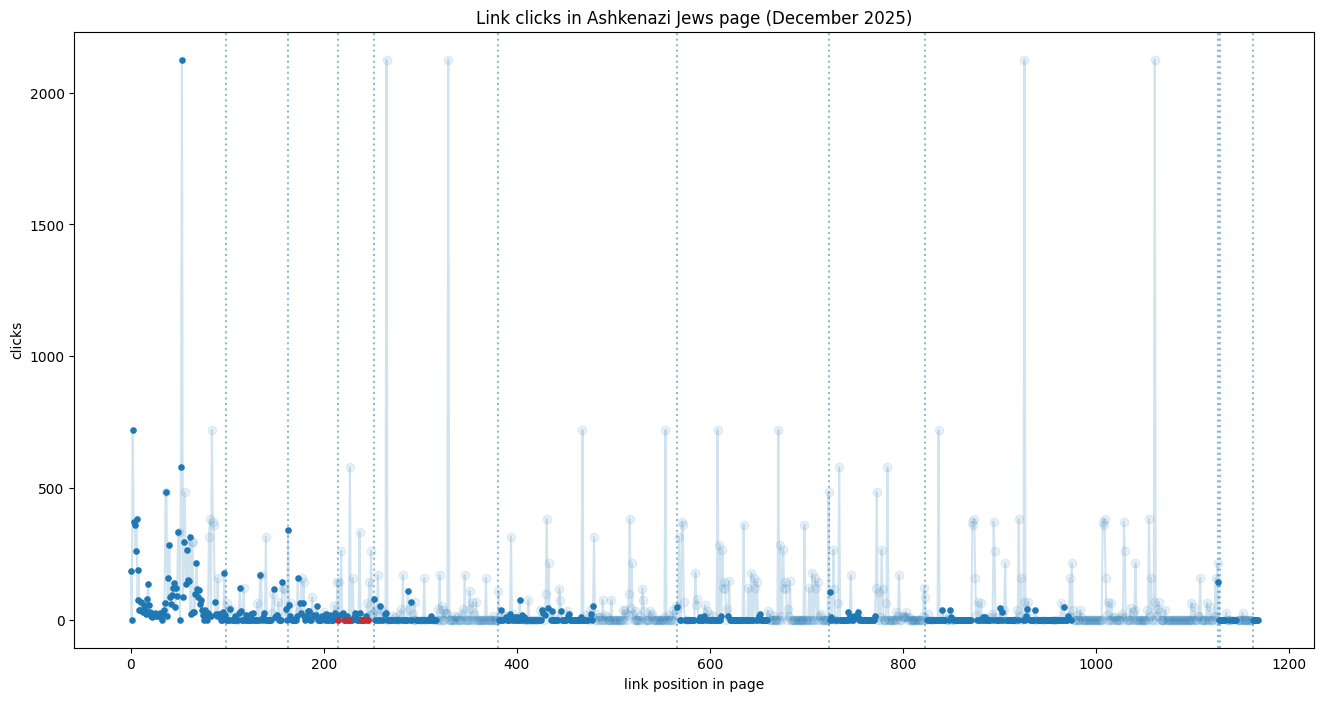

In [219]:
var = "clicks"
#var = "log_clicks"
plt.figure(figsize=(16,8))
point_size=14

idx = df_links_clicks["first_appearance"]

# 2nd+ appearances
plt.scatter(
    x=df_links_clicks[~idx].index,
    y=df_links_clicks[~idx][var],
    alpha=0.1
)

# 1st appearances
plt.scatter(
    x = df_links_clicks[idx].index,
    y=df_links_clicks[idx][var],
    color="tab:blue",
    s=point_size
)

# values
plt.plot(
    df_links_clicks[var],
    alpha=0.2
)

# genetics keywords
plt.scatter(
    x = df_links_clicks[idx_keywords].index,
    y = df_links_clicks[idx_keywords][var],
    color="tab:red",
    s=point_size
)

# section delimiters
for idx in idx_section:
    plt.axvline(
        x=idx,
        color='tab:blue',
        alpha=0.5,
        ls=":"
    )#, label='axvline - full height')

#x_pos = [0,83,150,500,610,650,690]
#y_pos = [8.5,8.5,8.5,8.5,8.2,7,8.5]
#labs = ["Introduction","Etymology","H    i    s    t    o    r    y","Definition","Customs,\nlaws,\nand traditions","Notable Ashkenazim","G  e  n  e  t  i  c  s"]

#for i in range(0, len(x_pos)):
#    if var=="log_clicks":
#        plt.annotate(xy=(x_pos[i],y_pos[i]),text=labs[i])
#    elif var=="clicks":
#        plt.annotate(xy=(x_pos[i],np.exp(y_pos[i])),text=labs[i])
#plt.annotate(xy=(0,8.7), text="Introduction")
#plt.annotate(xy=(83,8.7), text="Etymology")
#plt.annotate(xy=(150,8.7), text="H    i    s    t    o    r    y")
#plt.annotate(xy=(500,8.7), text="Definition")
#plt.annotate(xy=(610,8.2), text="Customs,\nlaws,\nand traditions")
#plt.annotate(xy=(650,7), text="Notable Ashkenazim")
#plt.annotate(xy=(690,8.5), text="G e n e t i c s")

plt.ylabel(var)
plt.xlabel("link position in page")
plt.title("Link clicks in Ashkenazi Jews page (December 2025)")

In [220]:
# Sort the links by clicks and look at their sections
total_clicks = 0
intro_clicks = 0
genetics_clicks = 0
genetics_non_intro_clicks = 0
counter = 1
for v in df_links_clicks[df_links_clicks["first_appearance"]].sort_values("clicks", ascending=False).values:
    if v[0]=="Introduction":
            intro_clicks+= v[-2]
    if any(keyword.lower() in v[5].lower() for keyword in genetics_terms) or any(keyword.lower() in v[0].lower() for keyword in genetics_terms):
        print(counter, "******", v[1], v[2], v[0], v[5], v[-2])
        genetics_clicks+= v[-2]
        if v[0]!="Introduction":
            genetics_non_intro_clicks+= v[-2]
    else:
        print(counter, v[1], v[2], v[0], v[5], v[-2])
    total_clicks+= v[-2]

    counter+= 1

1 0 1 Introduction Palestine_(region) 2125.0
2 0 1 Introduction Palestine 720.0
3 0 1 Introduction Levant 578.0
4 0 1 Introduction Palestinian_Arabic 484.0
5 0 1 Introduction Israel 383.0
6 0 1 Introduction West_Bank 372.0
7 0 1 Introduction Gaza_Strip 361.0
8 2 3 Origins Origin_of_the_Palestinians 341.0
9 0 1 Introduction Arabs 333.0
10 0 1 Introduction Mandatory_Palestine 315.0
11 0 1 Introduction Palestinian_identity 294.0
12 0 1 Introduction Sunni_Islam 285.0
13 0 1 Introduction Palestinian_Christians 266.0
14 0 1 Introduction Jordan 261.0
15 0 1 Introduction 1948_Palestinian_expulsion_and_flight 214.0
16 0 1 Introduction Chile 188.0
17 0 1 Introduction Flag_of_Palestine 183.0
18 0 1 Introduction Palestinians_in_Chile 178.0
19 1 2 Etymology Khalil_Beidas 169.0
20 0 1 Introduction Palestinian_diaspora 159.0
21 2 3 Origins Canaan 158.0
22 0 1 Introduction Third_Aliyah 151.0
23 0 1 Introduction Aliyah 147.0
24 1 2 Etymology Samaritans 144.0
25 9 28 See also List_of_Palestinians 143.0


In [221]:
genetics_clicks/total_clicks

0.012219821766135565

In [222]:
genetics_non_intro_clicks/(total_clicks-intro_clicks)

0.047049649077203014

In [109]:
df_links_clicks_first = df_links_clicks[df_links_clicks["first_appearance"]]

In [110]:
df_links_clicks_first.sort_values("clicks")

,section_title,top_level_section,overall_section,link,link_target,link_target_2,first_appearance,page_name,clicks,log_clicks
898,External links,11,37,Category:Ethnic groups in Poland,Category:Ethnic groups in Poland,Category:Ethnic_groups_in_Poland,True,0,0.0,0.000000
897,External links,11,37,Category:Jewish ethnic groups,Category:Jewish ethnic groups,Category:Jewish_ethnic_groups,True,0,0.0,0.000000
35,Introduction,0,1,Ireland,Ireland,Ireland,True,0,0.0,0.000000
60,Introduction,0,1,History of the Jews in Poland#Early history to...,History of the Jews in Poland#Early history to...,History_of_the_Jews_in_Poland#Early_history_to...,True,0,0.0,0.000000
43,Introduction,0,1,File: Star of David.svg,File: Star of David.svg,File:_Star_of_David.svg,True,0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...
42,Introduction,0,1,Yiddish,Yiddish,Yiddish,True,Yiddish,2674.0,7.891331
61,Introduction,0,1,Casimir III the Great,Casimir III the Great,Casimir_III_the_Great,True,Casimir_III_the_Great,2875.0,7.963808
57,Introduction,0,1,Rhineland,Rhineland,Rhineland,True,Rhineland,2923.0,7.980366
47,Introduction,0,1,Sephardic Jews,Sephardic Jews,Sephardic_Jews,True,Sephardic_Jews,3107.0,8.041413


In [111]:
positions = df_links_clicks_first.reset_index().index.values

In [112]:
hits = df_links_clicks_first["clicks"].values

In [113]:
# Poisson regression?
X = sm.add_constant(positions) # Adds the intercept
y = hits

# 3. Fit the Poisson Model
model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# 4. Calculate Predicted Clicks and Residuals
expected_clicks = model.predict(X)

In [114]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  421
Model:                            GLM   Df Residuals:                      419
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -78607.
Date:                Thu, 19 Mar 2026   Deviance:                   1.5569e+05
Time:                        10:29:36   Pearson chi2:                 5.51e+05
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1704      0.006    950.032      0.000       6.158       6.183
x1            -0.0087    4.7e-05   -185.202      0.000      -0.009      -0.009
==============================================================================
"""

In [115]:
model.pearson_chi2

np.float64(551216.1403702311)

In [116]:
model.df_resid

np.int64(419)

In [117]:
# Try NB model
nb_model = sm.GLM(y, X, family=sm.families.NegativeBinomial()).fit()

/oscar/home/adiazpap/wikistudy/wiki_venv_3_13_5/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [118]:
expected_clicks_nb = nb_model.predict(X)

In [119]:
# Calculate expected clicks, generate and standardize residuals
df_links_clicks_first.loc[:,"expected_clicks_nb"] = nb_model.predict(X)
df_links_clicks_first.loc[:,"residual"] = df_links_clicks_first["clicks"] - df_links_clicks_first["expected_clicks_nb"]
df_links_clicks_first.loc[:,"residual_standardized"] = (df_links_clicks_first["residual"] - df_links_clicks_first["residual"].mean())/df_links_clicks_first["residual"].std()


/tmp/ipykernel_2532077/4234855767.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_links_clicks_first.loc[:,"expected_clicks_nb"] = nb_model.predict(X)
/tmp/ipykernel_2532077/4234855767.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_links_clicks_first.loc[:,"residual"] = df_links_clicks_first["clicks"] - df_links_clicks_first["expected_clicks_nb"]
/tmp/ipykernel_2532077/4234855767.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

In [120]:
df_links_clicks_first.sort_values("residual_standardized", ascending=False)[:50]

,section_title,top_level_section,overall_section,link,link_target,link_target_2,first_appearance,page_name,clicks,log_clicks,expected_clicks_nb,residual,residual_standardized
53,Introduction,0,1,Jewish diaspora,Jewish diaspora,Jewish_diaspora,True,Jewish_diaspora,5232.0,8.562549,241.553903,4990.446097,11.457607
47,Introduction,0,1,Sephardic Jews,Sephardic Jews,Sephardic_Jews,True,Sephardic_Jews,3107.0,8.041413,251.122039,2855.877961,6.546391
57,Introduction,0,1,Rhineland,Rhineland,Rhineland,True,Rhineland,2923.0,7.980366,235.378547,2687.621453,6.159266
61,Introduction,0,1,Casimir III the Great,Casimir III the Great,Casimir_III_the_Great,True,Casimir_III_the_Great,2875.0,7.963808,229.361065,2645.638935,6.062673
686,Notable Ashkenazim,6,21,List of East European Jews,List of East European Jews,List_of_East_European_Jews,True,List_of_East_European_Jews,2511.0,7.828436,35.771280,2475.228720,5.670593
42,Introduction,0,1,Yiddish,Yiddish,Yiddish,True,Yiddish,2674.0,7.891331,259.384372,2414.615628,5.531134
49,Introduction,0,1,Jewish ethnic divisions,Jewish ethnic divisions,Jewish_ethnic_divisions,True,Jewish_ethnic_divisions,2198.0,7.695303,247.891274,1950.108726,4.462396
48,Introduction,0,1,Mizrahi Jews,Mizrahi Jews,Mizrahi_Jews,True,Mizrahi_Jews,1859.0,7.527794,249.501427,1609.498573,3.678720
59,Introduction,0,1,Persecution of Jews during the Black Death,Persecution of Jews during the Black Death,Persecution_of_Jews_during_the_Black_Death,True,Persecution_of_Jews_during_the_Black_Death,1698.0,7.437206,232.350327,1465.649673,3.347753
3,Introduction,0,1,Israel,Israel,Israel,True,Israel,1439.0,7.271704,333.890312,1105.109688,2.518222


In [121]:
np.sum(hits > expected_clicks_nb)

np.int64(71)

In [122]:
hits

array([ 153., 1092.,  245., 1439.,  119.,  884.,  142.,   63.,   48.,
         24.,   70.,   56.,   33.,   59.,   48.,   26.,   33.,   17.,
         19.,   32.,   59.,   21.,   33.,   27.,   30.,   33.,   36.,
         18.,   17.,   20.,   60.,   38.,   34.,   91.,   33.,    0.,
        137.,  169.,  359.,   15.,   10.,   18., 2674.,    0.,  501.,
        499., 1027., 3107., 1859., 2198.,  432.,   71.,   80., 5232.,
        108., 1041.,  481., 2923.,  806., 1698.,    0., 2875.,  961.,
        303.,  109.,  146.,  273.,   84.,   22.,    0.,  259.,  496.,
        125.,   70.,   48.,   32.,   16.,    0.,   15.,   23.,  883.,
        158.,   46.,   42.,  268.,  734.,  200.,  114.,  104.,   60.,
          0.,  200.,  464.,   50.,    0.,   37.,  126.,   12.,    0.,
         21.,   35.,   46.,   63.,  123.,   14.,    0.,   41.,   13.,
        353.,    0.,   16.,   26.,   22.,   67.,   13.,    0.,   84.,
         58.,    0.,   23.,   42.,    0.,   43.,   40.,  241.,   20.,
         18.,    0.,

In [123]:
expected_clicks

array([478.38901496, 474.24128596, 470.1295186 , 466.05340109,
       462.01262434, 458.00688194, 454.03587013, 450.09928779,
       446.19683642, 442.32822008, 438.49314542, 434.69132163,
       430.92246042, 427.186276  , 423.48248504, 419.8108067 ,
       416.17096255, 412.56267658, 408.98567517, 405.43968709,
       401.92444343, 398.43967765, 394.98512548, 391.56052498,
       388.16561646, 384.80014247, 381.46384782, 378.15647952,
       374.87778676, 371.62752093, 368.40543556, 365.21128632,
       362.04483099, 358.90582947, 355.79404372, 352.70923778,
       349.65117773, 346.61963168, 343.61436974, 340.63516402,
       337.68178862, 334.75401958, 331.85163488, 328.97441445,
       326.12214009, 323.29459552, 320.49156634, 317.71283998,
       314.95820574, 312.22745473, 309.52037989, 306.83677592,
       304.17643935, 301.53916842, 298.92476317, 296.33302533,
       293.76375839, 291.2167675 , 288.69185954, 286.18884304,
       283.70752819, 281.24772685, 278.80925247, 276.39

In [124]:
np.array(hits) > expected_clicks

array([False,  True, False,  True, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False,  True, False,  True,
        True,  True,  True,  True,  True,  True, False, False,  True,
       False,  True,  True,  True,  True,  True, False,  True,  True,
        True, False, False,  True, False, False, False, False,  True,
       False, False, False, False, False, False, False, False,  True,
       False, False, False,  True,  True, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False,

In [125]:
# Calculate spearman's rho for link position versus clicks
res = stats.spearmanrho(positions,hits)

In [126]:
# Plot the total number of clicks within sections
df_links_clicks.groupby("top_level_section").sum("clicks")

,overall_section,first_appearance,clicks,log_clicks
top_level_section,,,,
0,86,85,40525.0,391.193217
1,106,49,8285.0,179.745041
2,1986,143,65636.0,998.575045
3,1991,45,57431.0,342.000008
4,618,23,4044.0,65.969222
5,60,3,781.0,16.033537
6,21,1,2511.0,7.828436
7,4414,57,24087.0,466.881781
8,30,0,2198.0,7.695303


### Measure section lengths

In [127]:
# Copy text
# Since we are extracting plaintext from the parser we can skip the part where we parse wikilinks
revision_contents_substituted = revision_contents["Ashkenazi_Jews"]

In [128]:
parsed = wtp.parse(revision_contents_substituted)

In [129]:
# Note on plain_text vs string
section_titles = list()
section_levels = list()
section_lengths = list()

for section in parsed.sections:
    if section.title is None:
        section_title = "Introduction"
    else:
        section_title = section.title.strip()

    # Replace categories if necessary
    section_text = section.plain_text(replace_wikilinks=False)
    section_text = re.sub(r'\[\[CATEGORY:.*?\]\]','',
       section_text,
       flags=re.IGNORECASE)
    section_text = wtp.parse(section_text).plain_text()
    #section_text.replace("\n",""

    section_titles.append(section_title)
    section_levels.append(section.level)
    section_lengths.append(len(section_text))
    
    # Get rid of references/templates
    # nevermind, apparently not necessary!
    #for tag in section.get_tags():
    #    break
        #section_text = section_text.replace(str(tag.plain_text),"")
        
        #section_text = section_text.replace()
        #print(section.plain_text)

    print(section_text)

 






Ashkenazi Jews ( ; also known as Ashkenazic Jews), Ashkenazis, or Ashkenazim form a distinct subgroup of the Jewish diaspora that emerged in the Holy Roman Empire in the Early Middle Ages, originating from the Jewish communities who lived in the 10th century in the Rhineland valley and in neighbouring France before migrating eastward after the Crusades. Facing persecution in Western Europe, particularly following the Black Death in the 14th century, the bulk of the Ashkenazi Jews migrated to the Kingdom of Poland, at the encouragement of Casimir III the Great and his successors, making Poland the main centre of Ashkenazi Jewry until the Holocaust.Mosk (2013), p. 143. "Encouraged to move out of the Holy Roman Empire as persecution of their communities intensified during the twelfth and thirteenth centuries, the Ashkenazi community increasingly gravitated toward Poland."Harshav, Benjamin (1999). The Meaning of Yiddish. Stanford: Stanford University Press. p. 6. "From the fourteen

In [130]:
# Calculate running section lengths
parent_lengths = defaultdict(int)
parent_section = ""
parent_section_lengths = defaultdict(int)

#for i in range(0, len(section_titles)):
    #if section_levels[i] in [0,2]:
    #    parent_section = section_titles[i]

    #parent_lengths[parent_section]+=section_lengths[i]

    #print(section_levels[i], parent_section, "-", section_titles[i], section_lengths[i], parent_lengths[parent_section])
for i in range(0, len(section_titles)):
    if section_levels[i] in [0,2]:
        parent_section_lengths[section_titles[i]]+= section_lengths[i]
        

In [131]:
parent_section_lengths

defaultdict(int,
            {'Introduction': 3345,
             'Etymology': 3611,
             'History': 26035,
             'Definition': 10278,
             'Customs, laws, and traditions': 2788,
             'Relations with Sephardim': 820,
             'Notable Ashkenazim': 299,
             'Genetics': 22115,
             'See also': 40,
             'Explanatory notes': 24,
             'References': 1137,
             'External links': 368})

In [132]:
total_length = np.sum([parent_section_lengths[k] for k in parent_section_lengths.keys()])
for k in parent_section_lengths.keys():
    print(k, round(parent_section_lengths[k]/total_length, 3))

Introduction 0.047
Etymology 0.051
History 0.367
Definition 0.145
Customs, laws, and traditions 0.039
Relations with Sephardim 0.012
Notable Ashkenazim 0.004
Genetics 0.312
See also 0.001
Explanatory notes 0.0
References 0.016
External links 0.005


In [133]:
total_length

np.int64(70860)

### Manuscript tables and plots

In [134]:
df_links_clicks_first

,section_title,top_level_section,overall_section,link,link_target,link_target_2,first_appearance,page_name,clicks,log_clicks,expected_clicks_nb,residual,residual_standardized
0,Introduction,0,1,Ashkenazi (surname),Ashkenazi (surname),Ashkenazi_(surname),True,Ashkenazi_(surname),153.0,5.030438,340.438919,-187.438919,-0.455675
1,Introduction,0,1,Jews Praying in the Synagogue on Yom Kippur,Jews Praying in the Synagogue on Yom Kippur,Jews_Praying_in_the_Synagogue_on_Yom_Kippur,True,Jews_Praying_in_the_Synagogue_on_Yom_Kippur,1092.0,6.995766,338.241902,753.758098,1.709832
2,Introduction,0,1,United States,United States,United_States,True,United_States,245.0,5.501258,336.059064,-91.059064,-0.233924
3,Introduction,0,1,Israel,Israel,Israel,True,Israel,1439.0,7.271704,333.890312,1105.109688,2.518222
4,Introduction,0,1,Russia,Russia,Russia,True,Russia,119.0,4.779123,331.735556,-212.735556,-0.513877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
894,External links,11,37,Category:Ashkenazi Jews,Category:Ashkenazi Jews,Category:Ashkenazi_Jews,True,0,0.0,0.000000,23.032040,-23.032040,-0.077407
895,External links,11,37,Category:Ethnic groups in Israel,Category:Ethnic groups in Israel,Category:Ethnic_groups_in_Israel,True,0,0.0,0.000000,22.883403,-22.883403,-0.077065
896,External links,11,37,Category:Ethnic groups in Russia,Category:Ethnic groups in Russia,Category:Ethnic_groups_in_Russia,True,0,0.0,0.000000,22.735726,-22.735726,-0.076726
897,External links,11,37,Category:Jewish ethnic groups,Category:Jewish ethnic groups,Category:Jewish_ethnic_groups,True,0,0.0,0.000000,22.589001,-22.589001,-0.076388


In [135]:
section_lengths = pd.DataFrame(
    {
        "section_title":[k for k in parent_section_lengths.keys()],
        "section_length":[parent_section_lengths[k] for k in parent_section_lengths.keys()],
        "top_level_section":[i for i in range(len(parent_section_lengths.keys()))]
    }
)

In [136]:
section_lengths

,section_title,section_length,top_level_section
0,Introduction,3345,0
1,Etymology,3611,1
2,History,26035,2
3,Definition,10278,3
4,"Customs, laws, and traditions",2788,4
5,Relations with Sephardim,820,5
6,Notable Ashkenazim,299,6
7,Genetics,22115,7
8,See also,40,8
9,Explanatory notes,24,9


In [137]:
clicks_summary = df_links_clicks_first.groupby("top_level_section").sum("clicks").reset_index()

In [138]:
clicks_summary

,top_level_section,overall_section,first_appearance,clicks,log_clicks,expected_clicks_nb,residual,residual_standardized
0,0,85,85,37851.0,383.301886,22326.907590,15524.092410,33.642540
1,1,98,49,3722.0,153.030256,8271.200559,-4549.200559,-11.663156
2,2,429,143,5800.0,304.991256,13376.986898,-7576.986898,-20.924531
3,3,585,45,455.0,35.740025,2218.498476,-1763.498476,-5.156149
4,4,414,23,312.0,32.966921,907.485456,-595.485456,-1.931646
5,5,60,3,781.0,16.033537,108.713980,672.286020,1.473550
6,6,21,1,2511.0,7.828436,35.771280,2475.228720,5.670593
7,7,1254,57,2333.0,116.798132,1699.527457,633.472543,0.065820
8,10,288,9,0.0,0.000000,215.529325,-215.529325,-0.715628
9,11,222,6,0.0,0.000000,136.865035,-136.865035,-0.461391


In [139]:
clicks_summary = pd.merge(
    left = section_lengths,
    right = clicks_summary,
    how="left",
    left_on="top_level_section",
    right_on="top_level_section"
)

In [140]:
clicks_summary

,section_title,section_length,top_level_section,overall_section,first_appearance,clicks,log_clicks,expected_clicks_nb,residual,residual_standardized
0,Introduction,3345,0,85.0,85.0,37851.0,383.301886,22326.907590,15524.092410,33.642540
1,Etymology,3611,1,98.0,49.0,3722.0,153.030256,8271.200559,-4549.200559,-11.663156
2,History,26035,2,429.0,143.0,5800.0,304.991256,13376.986898,-7576.986898,-20.924531
3,Definition,10278,3,585.0,45.0,455.0,35.740025,2218.498476,-1763.498476,-5.156149
4,"Customs, laws, and traditions",2788,4,414.0,23.0,312.0,32.966921,907.485456,-595.485456,-1.931646
5,Relations with Sephardim,820,5,60.0,3.0,781.0,16.033537,108.713980,672.286020,1.473550
6,Notable Ashkenazim,299,6,21.0,1.0,2511.0,7.828436,35.771280,2475.228720,5.670593
7,Genetics,22115,7,1254.0,57.0,2333.0,116.798132,1699.527457,633.472543,0.065820
8,See also,40,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Explanatory notes,24,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


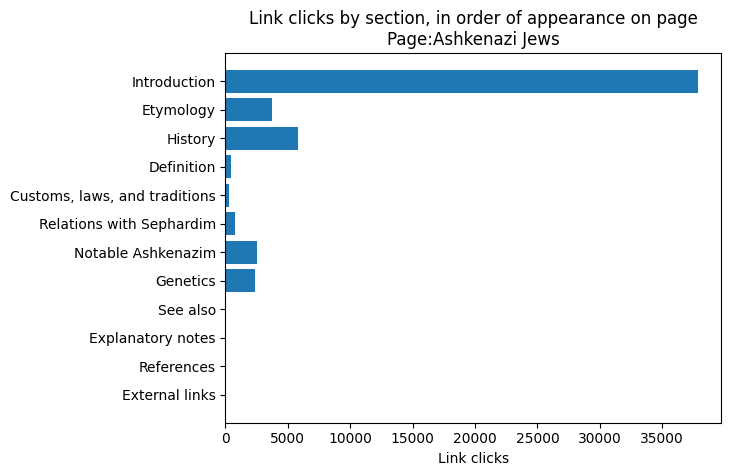

In [141]:
fig, ax = plt.subplots()

# Example data
ylabs = clicks_summary["section_title"].values
ypos = np.arange(len(ylabs))
xvals = clicks_summary["clicks"].values

ax.barh(ypos, xvals)
ax.set_yticks(ypos, labels=ylabs)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel("Link clicks")
ax.set_title("Link clicks by section, in order of appearance on page\nPage:" + page_name.replace("_"," "))

plt.show()

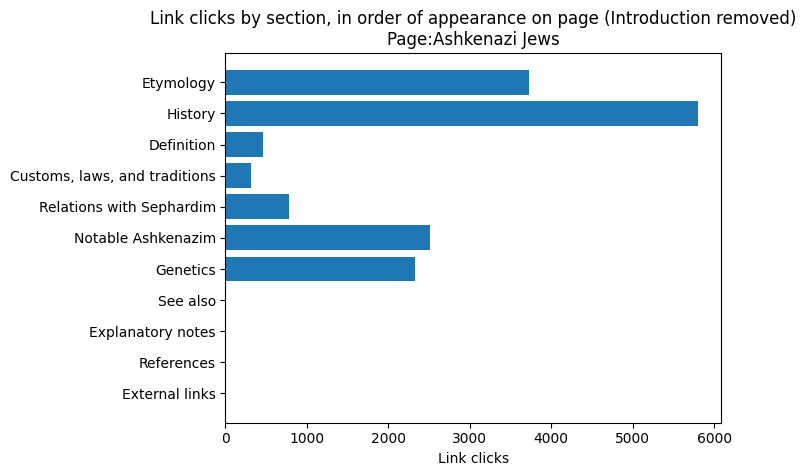

In [142]:
fig, ax = plt.subplots()

# Example data
ylabs = clicks_summary["section_title"].values[1:]
ypos = np.arange(len(ylabs))
xvals = clicks_summary["clicks"].values[1:]

ax.barh(ypos, xvals)
ax.set_yticks(ypos, labels=ylabs)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel("Link clicks")
ax.set_title("Link clicks by section, in order of appearance on page (Introduction removed)\nPage:" + page_name.replace("_"," "))

plt.show()

# Functional general version: Clickstream measurements

Start with the clickstream data (for each of the pages), then append the redirects, then do the analyses. This would probably get around a lot of the more frustrating issues....

Set up a dataframe with the following columns:
* `page`
* `out_link`
* `redirect`
* `out_clicks`

Given this, we can subset the data for each case study and make some easier joins.

In [19]:
# Build the dataframe of outlinks and their clicks
# This is based off of clickstream data
page_names = []
outlinks = []
outclicks = []

for k in clicks_out.keys():
    for i in clicks_out[k]:
        page_names.append(k)
        outlinks.append(i[1])
        outclicks.append(int(i[3]))

df_outclicks = pd.DataFrame(
    {
        "page":page_names,
        "out_link":outlinks,
        "out_clicks":outclicks,
    }
)

In [20]:
# Join the redirect data
# This is retrieved from the Wikipedia API on all clickstream links
page_names = []
targets = []
redirects = []

for k in link_dict.keys():
    # Loop over each page we are analyzing
    for i in link_dict[k].keys():
        # Loop over each redirect (i is the redirect, link_dict[k][i] is the target)
        page_names.append(k.replace(" ","_"))
        redirects.append(i.replace(" ","_"))
        targets.append(link_dict[k][i].replace(" ","_"))

    for v in set(link_dict[k].values()):
        # Add the trivial redirect (the redirect is the page itself)
        page_names.append(k.replace(" ","_"))
        redirects.append(v.replace(" ","_"))
        targets.append(v.replace(" ","_"))

df_redirects = pd.DataFrame(
    {
        "page":page_names,
        "redirect":redirects,
        "target":targets
    }
)

In [21]:
# Connect the two
df_redirect_clicks = pd.merge(
    left = df_outclicks,
    right = df_redirects,
    how = "left",
    left_on = ["page","out_link"],
    right_on = ["page","target"]
)

In [22]:
# Drop redundant variable
df_redirect_clicks = df_redirect_clicks.drop("out_link", axis=1)

In [23]:
df_redirect_clicks

,page,out_clicks,redirect,target
0,Ashkenazi_Jews,5232,Jewish_Diaspora,Jewish_diaspora
1,Ashkenazi_Jews,5232,Galut,Jewish_diaspora
2,Ashkenazi_Jews,5232,Galus,Jewish_diaspora
3,Ashkenazi_Jews,5232,Jewish_diasporah,Jewish_diaspora
4,Ashkenazi_Jews,5232,Jewish_exile,Jewish_diaspora
...,...,...,...,...
18444,Black_people,13,Ulciǌ,Ulcinj
18445,Black_people,13,Airport_Ulcinj,Ulcinj
18446,Black_people,13,Aerodrom_Ulcinj,Ulcinj
18447,Black_people,13,Aeroporti_Ulqini,Ulcinj


## Link data

Connect all the data:
* Links within a page
* Redirects
* Clickstream data

In the end, we'll have a dataset that contains the number of clicks for every link by section and sub-section

In [26]:
page_name = "Ashkenazi_Jews"

In [27]:
revision_contents_substituted = revision_contents[page_name]

if page_name=="Ashkenazi_Jews":
    ##### "ASHKENAZI JEWS" CASE STUDY #####
    # Navigation templates
    revision_contents_substituted = revision_contents_substituted.replace("{{Jews and Judaism sidebar|communities}}","")
    revision_contents_substituted = revision_contents_substituted.replace("{{Demographics of Israel}}","")
    revision_contents_substituted = revision_contents_substituted.replace("{{Jews and Judaism}}","")
elif page_name=="Black_people":
    ##### "BLACK PEOPLE" CASE STUDY #####
    revision_contents_substituted = revision_contents_substituted.replace("{{Black people sidebar}}","")
    revision_contents_substituted = revision_contents_substituted.replace("{{Redirect|Blacks|other uses|Blacks (disambiguation)}}","Blacks (disambiguation)")
elif page_name=="White_people":
    revision_contents_substituted = revision_contents_substituted.replace("{{Race}}","")
    revision_contents_substituted = revision_contents_substituted.replace("{{redirect-several|White people|Whites|White man|}}",
                                                                      "[[White people (disambiguation)]]\n[[Whites (disambiguation)]]\n[[White man (disambiguation)]]")

In [28]:
##### ALL CASE STUDIES #####
revision_contents_substituted = re.sub(r'\{\{flag\|(.*?)\}\}',r'[[\1]]', revision_contents_substituted, flags=re.IGNORECASE) # {{flag}} template

# Special cases (multiple parameters)
# {{main}}, {{see also}}, {{further}}
revision_contents_substituted = re.sub(r'\{\{main\|(.*?)\}\}', transform_match, revision_contents_substituted, flags=re.IGNORECASE)
revision_contents_substituted = re.sub(r'\{\{see also\|(.*?)\}\}', transform_match, revision_contents_substituted, flags=re.IGNORECASE)
revision_contents_substituted = re.sub(r'\{\{further\|(.*?)\}\}', transform_match, revision_contents_substituted, flags=re.IGNORECASE)

# Get rid of documentation templates
revision_contents_substituted = re.sub(r'<noinclude>.*?<\/noinclude>','',revision_contents_substituted)

In [29]:
parsed = wtp.parse(revision_contents_substituted)

In [30]:
for tag in parsed.get_tags():
    revision_contents_substituted = revision_contents_substituted.replace(tag.string,"")

In [31]:
# Rewrite to make sure that the links are being translated correctly
# Assign sections to links
section_links = defaultdict(set)
top_section_counter = 0 # Intro and top-level
sub_section_counter = 0 # Sub-sections (actually ignoring this for now)
section_counter = 0 # 

subsection_title = ""

section_titles = []
top_section_list = []
overall_section_list = []
link_list = []
subsection_indicators = [] # Indicate if a link is from a subsection or from the parent section (not implemented, may be useful for subsection analysis)

var = 0

# Note that sub-sections are considered part of the parent section
# i.e. a level-2 section's contents contains all of its subsections' contents as well
# This doesn't matter for section-level analyses, but does for subsection-level analyses

## Cheap hack: Check if the section is a subsection by comparing levels
## Section levels are 0 for intro, and then the smallest non-zero value is the parent-section-level for this page
## Note that we can have (e.g.) an h3 heading as the first section and then h2 as the second section
## So this isn't fool proof. But perhaps I'm the fool to prove it.
if len(parsed.sections) == 1:
    # No sections: minimum level is 0
    min_level = 0
elif len(parsed.sections) > 1:
    # Sections are present
    min_level = np.min([section.level for section in parsed.sections[1:]])

for section in parsed.sections:
    print("NEW SECTION")
    print("TITLE:", section.title)
    print("LEVEL:", section.level)
    if section.level==2:
    #if section.level<=min_level:
        top_section_counter+= 1
        sub_section_counter = 0
    #    subsection_indicator = False
    #elif section.level > min_level:
    #    subsection_indicator = True
    
    for link in section.wikilinks:
        relative_section = str(top_section_counter) + "." + str(sub_section_counter)
        if section.title is None:
            section_title = "Introduction"
        else:
            section_title = section.title

        # Get the target link and check if it's in our dictionary of redirects
        target = link.target.split("#")[0]
        link_list.append(target)

        print(var, "Overall:", section_counter, "", top_section_counter, section_title, target)

        section_titles.append(section_title)
        section_links[top_section_counter].add(target.replace(" ","_").lower())
        #subsection_indicators.append(subsection_indicator)

        top_section_list.append(top_section_counter)
        overall_section_list.append(section_counter)

        var+=1

    section_counter+= 1

NEW SECTION
TITLE: None
LEVEL: 0
0 Overall: 0  0 Introduction Jews Praying in the Synagogue on Yom Kippur
1 Overall: 0  0 Introduction Hebrew University of Jerusalem
2 Overall: 0  0 Introduction United States
3 Overall: 0  0 Introduction Israel Medical Association Journal
4 Overall: 0  0 Introduction Israel
5 Overall: 0  0 Introduction Russia
6 Overall: 0  0 Introduction Federation of Jewish Communities of Russia
7 Overall: 0  0 Introduction Argentina
8 Overall: 0  0 Introduction United Kingdom
9 Overall: 0  0 Introduction Canada
10 Overall: 0  0 Introduction France
11 Overall: 0  0 Introduction Germany
12 Overall: 0  0 Introduction Ukraine
13 Overall: 0  0 Introduction Australia
14 Overall: 0  0 Introduction South Africa
15 Overall: 0  0 Introduction Belarus
16 Overall: 0  0 Introduction Brazil
17 Overall: 0  0 Introduction Hungary
18 Overall: 0  0 Introduction Chile
19 Overall: 0  0 Introduction Belgium
20 Overall: 0  0 Introduction Netherlands
21 Overall: 0  0 Introduction Moldova
2

In [32]:
# Convert links to data frame
section_links = pd.DataFrame(
    {
        "parent_section_index":top_section_list,
        "overall_section_index":overall_section_list,
        "link_target":link_list,
    }
)

In [33]:
section_links

,parent_section_index,overall_section_index,link_target
0,0,0,Jews Praying in the Synagogue on Yom Kippur
1,0,0,Hebrew University of Jerusalem
2,0,0,United States
3,0,0,Israel Medical Association Journal
4,0,0,Israel
...,...,...,...
986,11,36,Category:Ashkenazi Jews
987,11,36,Category:Ethnic groups in Israel
988,11,36,Category:Ethnic groups in Russia
989,11,36,Category:Jewish ethnic groups


In [34]:
df_redirect_clicks[df_redirect_clicks["page"]==page_name]

,page,out_clicks,redirect,target
0,Ashkenazi_Jews,5232,Jewish_Diaspora,Jewish_diaspora
1,Ashkenazi_Jews,5232,Galut,Jewish_diaspora
2,Ashkenazi_Jews,5232,Galus,Jewish_diaspora
3,Ashkenazi_Jews,5232,Jewish_diasporah,Jewish_diaspora
4,Ashkenazi_Jews,5232,Jewish_exile,Jewish_diaspora
...,...,...,...,...
6324,Ashkenazi_Jews,13,Titus_Flāvius_Caesar_Vespasiānus_Augustus,Vespasian
6325,Ashkenazi_Jews,13,VESPASIAN,Vespasian
6326,Ashkenazi_Jews,13,VESPASIANVS,Vespasian
6327,Ashkenazi_Jews,13,The_Emperor_Vespasian,Vespasian


In [35]:
temp1 = section_links
temp1.loc[:,"link_target2"] = temp1["link_target"].str.replace(" ","_")

temp2 = df_redirect_clicks[df_redirect_clicks["page"]==page_name]

section_links_clicks = pd.merge(
    left = temp1,
    right = temp2,
    how = "left",
    left_on = "link_target2",
    right_on = "redirect"
)

section_links_clicks = section_links_clicks.fillna(0)

In [36]:
section_links_clicks

,parent_section_index,overall_section_index,link_target,link_target2,page,out_clicks,redirect,target
0,0,0,Jews Praying in the Synagogue on Yom Kippur,Jews_Praying_in_the_Synagogue_on_Yom_Kippur,Ashkenazi_Jews,1092.0,Jews_Praying_in_the_Synagogue_on_Yom_Kippur,Jews_Praying_in_the_Synagogue_on_Yom_Kippur
1,0,0,Hebrew University of Jerusalem,Hebrew_University_of_Jerusalem,0,0.0,0,0
2,0,0,United States,United_States,Ashkenazi_Jews,245.0,United_States,United_States
3,0,0,Israel Medical Association Journal,Israel_Medical_Association_Journal,0,0.0,0,0
4,0,0,Israel,Israel,Ashkenazi_Jews,1439.0,Israel,Israel
...,...,...,...,...,...,...,...,...
986,11,36,Category:Ashkenazi Jews,Category:Ashkenazi_Jews,0,0.0,0,0
987,11,36,Category:Ethnic groups in Israel,Category:Ethnic_groups_in_Israel,0,0.0,0,0
988,11,36,Category:Ethnic groups in Russia,Category:Ethnic_groups_in_Russia,0,0.0,0,0
989,11,36,Category:Jewish ethnic groups,Category:Jewish_ethnic_groups,0,0.0,0,0


In [37]:
# Links that only appear once in the entire page
unique_links = section_links_clicks[section_links_clicks["link_target2"].isin(section_links["link_target2"].value_counts()[section_links["link_target2"].value_counts()==1].index)]
unique_links = unique_links[unique_links["out_clicks"]>0]

for v in unique_links.values:
    print(v)

[0 0 'Jews Praying in the Synagogue on Yom Kippur'
 'Jews_Praying_in_the_Synagogue_on_Yom_Kippur' 'Ashkenazi_Jews' 1092.0
 'Jews_Praying_in_the_Synagogue_on_Yom_Kippur'
 'Jews_Praying_in_the_Synagogue_on_Yom_Kippur']
[0 0 'United States' 'United_States' 'Ashkenazi_Jews' 245.0
 'United_States' 'United_States']
[0 0 'Israel' 'Israel' 'Ashkenazi_Jews' 1439.0 'Israel' 'Israel']
[0 0 'Russia' 'Russia' 'Ashkenazi_Jews' 119.0 'Russia' 'Russia']
[0 0 'Federation of Jewish Communities of Russia'
 'Federation_of_Jewish_Communities_of_Russia' 'Ashkenazi_Jews' 884.0
 'Federation_of_Jewish_Communities_of_Russia'
 'Federation_of_Jewish_Communities_of_Russia']
[0 0 'United Kingdom' 'United_Kingdom' 'Ashkenazi_Jews' 63.0
 'United_Kingdom' 'United_Kingdom']
[0 0 'Canada' 'Canada' 'Ashkenazi_Jews' 48.0 'Canada' 'Canada']
[0 0 'France' 'France' 'Ashkenazi_Jews' 24.0 'France' 'France']
[0 0 'Germany' 'Germany' 'Ashkenazi_Jews' 70.0 'Germany' 'Germany']
[0 0 'Ukraine' 'Ukraine' 'Ashkenazi_Jews' 56.0 'Ukrai

In [39]:
section_links_clicks

,parent_section_index,overall_section_index,link_target,link_target2,page,out_clicks,redirect,target
0,0,0,Jews Praying in the Synagogue on Yom Kippur,Jews_Praying_in_the_Synagogue_on_Yom_Kippur,Ashkenazi_Jews,1092.0,Jews_Praying_in_the_Synagogue_on_Yom_Kippur,Jews_Praying_in_the_Synagogue_on_Yom_Kippur
1,0,0,Hebrew University of Jerusalem,Hebrew_University_of_Jerusalem,0,0.0,0,0
2,0,0,United States,United_States,Ashkenazi_Jews,245.0,United_States,United_States
3,0,0,Israel Medical Association Journal,Israel_Medical_Association_Journal,0,0.0,0,0
4,0,0,Israel,Israel,Ashkenazi_Jews,1439.0,Israel,Israel
...,...,...,...,...,...,...,...,...
986,11,36,Category:Ashkenazi Jews,Category:Ashkenazi_Jews,0,0.0,0,0
987,11,36,Category:Ethnic groups in Israel,Category:Ethnic_groups_in_Israel,0,0.0,0,0
988,11,36,Category:Ethnic groups in Russia,Category:Ethnic_groups_in_Russia,0,0.0,0,0
989,11,36,Category:Jewish ethnic groups,Category:Jewish_ethnic_groups,0,0.0,0,0


In [40]:
# Reduce to first appearances
section_links_clicks.drop_duplicates("target", inplace=True, keep="first")

In [41]:
for v in section_links_clicks.values:
    print(v)

[0 0 'Jews Praying in the Synagogue on Yom Kippur'
 'Jews_Praying_in_the_Synagogue_on_Yom_Kippur' 'Ashkenazi_Jews' 1092.0
 'Jews_Praying_in_the_Synagogue_on_Yom_Kippur'
 'Jews_Praying_in_the_Synagogue_on_Yom_Kippur']
[0 0 'Hebrew University of Jerusalem' 'Hebrew_University_of_Jerusalem' 0
 0.0 0 0]
[0 0 'United States' 'United_States' 'Ashkenazi_Jews' 245.0
 'United_States' 'United_States']
[0 0 'Israel' 'Israel' 'Ashkenazi_Jews' 1439.0 'Israel' 'Israel']
[0 0 'Russia' 'Russia' 'Ashkenazi_Jews' 119.0 'Russia' 'Russia']
[0 0 'Federation of Jewish Communities of Russia'
 'Federation_of_Jewish_Communities_of_Russia' 'Ashkenazi_Jews' 884.0
 'Federation_of_Jewish_Communities_of_Russia'
 'Federation_of_Jewish_Communities_of_Russia']
[0 0 'Argentina' 'Argentina' 'Ashkenazi_Jews' 142.0 'Argentina'
 'Argentina']
[0 0 'United Kingdom' 'United_Kingdom' 'Ashkenazi_Jews' 63.0
 'United_Kingdom' 'United_Kingdom']
[0 0 'Canada' 'Canada' 'Ashkenazi_Jews' 48.0 'Canada' 'Canada']
[0 0 'France' 'France' '

In [42]:
# Output to table
#section_links_clicks[["page","parent_section_index","overall_section_index","target","link_target","out_clicks"]].to_csv(
#    os.path.join("tables", page_name + "_link_clicks_first.tsv"),
#    index = False,
#    sep = "\t"
#)

## Measure section lengths

For each section, measure how many plaintext characters there are.

In [43]:
# Note on plain_text vs string
section_titles = list()
section_levels = list()
section_lengths = list()

for section in parsed.sections:
    if section.title is None:
        section_title = "Introduction"
    else:
        section_title = section.title.strip()

    # Replace categories if necessary
    section_text = section.plain_text(replace_wikilinks=False)
    section_text = re.sub(r'\[\[CATEGORY:.*?\]\]','',
       section_text,
       flags=re.IGNORECASE)
    section_text = wtp.parse(section_text).plain_text()

    section_titles.append(section_title)
    section_levels.append(section.level)
    section_lengths.append(len(section_text))

In [44]:
# Calculate running section lengths
parent_lengths = defaultdict(int)
parent_section = ""
parent_section_lengths = defaultdict(int)

for i in range(0, len(section_titles)):
    if section_levels[i] in [0,2]:
        parent_section_lengths[section_titles[i]]+= section_lengths[i]        

In [45]:
# Get the total length and the proportion for each section
total_length = np.sum([parent_section_lengths[k] for k in parent_section_lengths.keys()])
for k in parent_section_lengths.keys():
    print(k, round(parent_section_lengths[k]/total_length, 3))

Introduction 0.047
Etymology 0.051
History 0.367
Definition 0.145
Customs, laws, and traditions 0.039
Relations with Sephardim 0.012
Notable Ashkenazim 0.005
Genetics 0.312
See also 0.001
Explanatory notes 0.0
References 0.016
External links 0.005


## Generate tables and figures

Get some statistics for the page:
* Clicks per section
* Links per section
* Characters per section

In [46]:
# Characters per section
section_summary = pd.DataFrame(
    {
        "section_title":[k for k in parent_section_lengths.keys()],
        "section_length":[parent_section_lengths[k] for k in parent_section_lengths.keys()],
        "top_level_section":[i for i in range(len(parent_section_lengths.keys()))]
    }
)



In [47]:
section_summary

,section_title,section_length,top_level_section
0,Introduction,3345,0
1,Etymology,3611,1
2,History,26102,2
3,Definition,10291,3
4,"Customs, laws, and traditions",2804,4
5,Relations with Sephardim,877,5
6,Notable Ashkenazim,321,6
7,Genetics,22201,7
8,See also,40,8
9,Explanatory notes,24,9


In [48]:
# Most-clicked links
section_links_clicks.sort_values("out_clicks", ascending=False)[:25].reset_index()

,index,parent_section_index,overall_section_index,link_target,link_target2,page,out_clicks,redirect,target
0,56,0,0,Jewish diaspora,Jewish_diaspora,Ashkenazi_Jews,5232.0,Jewish_diaspora,Jewish_diaspora
1,48,0,0,Sephardi Jews,Sephardi_Jews,Ashkenazi_Jews,3107.0,Sephardi_Jews,Sephardic_Jews
2,61,0,0,Rhineland,Rhineland,Ashkenazi_Jews,2923.0,Rhineland,Rhineland
3,65,0,0,Casimir III the Great,Casimir_III_the_Great,Ashkenazi_Jews,2875.0,Casimir_III_the_Great,Casimir_III_the_Great
4,43,0,0,Yiddish,Yiddish,Ashkenazi_Jews,2674.0,Yiddish,Yiddish
5,733,6,20,List of Ashkenazi Jews,List_of_Ashkenazi_Jews,Ashkenazi_Jews,2511.0,List_of_Ashkenazi_Jews,List_of_East_European_Jews
6,50,0,0,Jewish ethnic divisions,Jewish_ethnic_divisions,Ashkenazi_Jews,2198.0,Jewish_ethnic_divisions,Jewish_ethnic_divisions
7,49,0,0,Mizrahi Jews,Mizrahi_Jews,Ashkenazi_Jews,1859.0,Mizrahi_Jews,Mizrahi_Jews
8,63,0,0,Persecution of Jews during the Black Death,Persecution_of_Jews_during_the_Black_Death,Ashkenazi_Jews,1698.0,Persecution_of_Jews_during_the_Black_Death,Persecution_of_Jews_during_the_Black_Death
9,4,0,0,Israel,Israel,Ashkenazi_Jews,1439.0,Israel,Israel


In [49]:
section_links_clicks.groupby("parent_section_index").sum(numeric_only=True).reset_index()

,parent_section_index,overall_section_index,out_clicks
0,0,0,37720.0
1,1,37,3685.0
2,2,152,5455.0
3,3,120,436.0
4,4,136,239.0
5,5,76,1156.0
6,6,20,2511.0
7,7,525,2150.0


In [50]:
# Clicks out per section
clicks_summary = section_links_clicks.groupby("parent_section_index").sum(numeric_only=True).reset_index()
clicks_summary.drop("overall_section_index", axis=1, inplace=True)

In [51]:
clicks_summary

,parent_section_index,out_clicks
0,0,37720.0
1,1,3685.0
2,2,5455.0
3,3,436.0
4,4,239.0
5,5,1156.0
6,6,2511.0
7,7,2150.0


In [52]:
# Merge the two
page_summary = pd.merge(
    left = section_summary,
    right = clicks_summary,
    how = "left",
    left_on = "top_level_section",
    right_on = "parent_section_index"
)

page_summary.fillna(0, inplace=True) # Some sections have no first-appearance links with clicks
page_summary.drop("parent_section_index", axis=1, inplace=True) # Redundant variable used for join
page_summary["percent_length"] = page_summary["section_length"]/np.sum(page_summary["section_length"])
page_summary["percent_clicks"] = page_summary["out_clicks"]/np.sum(page_summary["out_clicks"])

In [53]:
# View for my convenience
page_summary[["top_level_section","section_title","section_length","percent_length","out_clicks","percent_clicks"]]

,top_level_section,section_title,section_length,percent_length,out_clicks,percent_clicks
0,0,Introduction,3345,0.047033,37720.0,0.707003
1,1,Etymology,3611,0.050773,3685.0,0.069070
2,2,History,26102,0.367008,5455.0,0.102245
3,3,Definition,10291,0.144697,436.0,0.008172
4,4,"Customs, laws, and traditions",2804,0.039426,239.0,0.004480
5,5,Relations with Sephardim,877,0.012331,1156.0,0.021667
6,6,Notable Ashkenazim,321,0.004513,2511.0,0.047065
7,7,Genetics,22201,0.312158,2150.0,0.040298
8,8,See also,40,0.000562,0.0,0.000000
9,9,Explanatory notes,24,0.000337,0.0,0.000000


In [54]:
np.sum(page_summary["section_length"])

np.int64(71121)

In [55]:
np.sum(page_summary["out_clicks"])

np.float64(53352.0)

In [56]:
# Save table to file
#page_summary[["top_level_section","section_title","section_length","percent_length","out_clicks","percent_clicks"]].to_csv(
#    os.path.join("tables", page_name + "_sections.tsv"),
#    index = False,
#    sep = "\t"
#)

In [57]:
# Subsection lengths (this uses the section lengths table above to determine the length relative to the overall page)
subsection_summary = pd.DataFrame(
    {
        "section_level": section_levels,
        "section_title": section_titles,
        "section_length": section_lengths
    }
)

subsection_summary["percent_length"]=subsection_summary["section_length"]/np.sum(page_summary["section_length"])

In [58]:
subsection_summary

,section_level,section_title,section_length,percent_length
0,0,Introduction,3345,0.047033
1,2,Etymology,3611,0.050773
2,2,History,26102,0.367008
3,3,Early Jewish communities in Europe,2054,0.028880
4,3,Jewish–Roman Wars,2826,0.039735
5,3,Late antiquity,4718,0.066338
6,3,Early Middle Ages,1405,0.019755
7,3,High and Late Middle Ages migrations,6593,0.092701
8,3,Modern history,7704,0.108322
9,4,The Holocaust,1589,0.022342


In [59]:
# Save table to file
#subsection_summary.to_csv(
#    os.path.join("tables", page_name + "_subsections.tsv"),
#    index = False,
#    sep = "\t"
#)

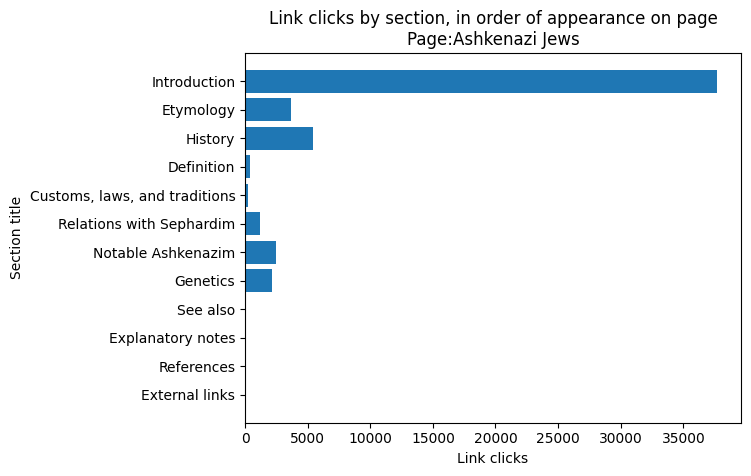

In [60]:
fig, ax = plt.subplots()

# Example data
ylabs = page_summary["section_title"].values
ypos = np.arange(len(ylabs))
xvals = page_summary["out_clicks"].values

ax.barh(ypos, xvals)
ax.set_yticks(ypos, labels=ylabs)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_ylabel("Section title")
ax.set_xlabel("Link clicks")
ax.set_title("Link clicks by section, in order of appearance on page\nPage:" + page_name.replace("_"," "))

#plt.savefig("figures/case_studies_clicks_" + page_name + ".svg", dpi=600, bbox_inches="tight")

plt.show()

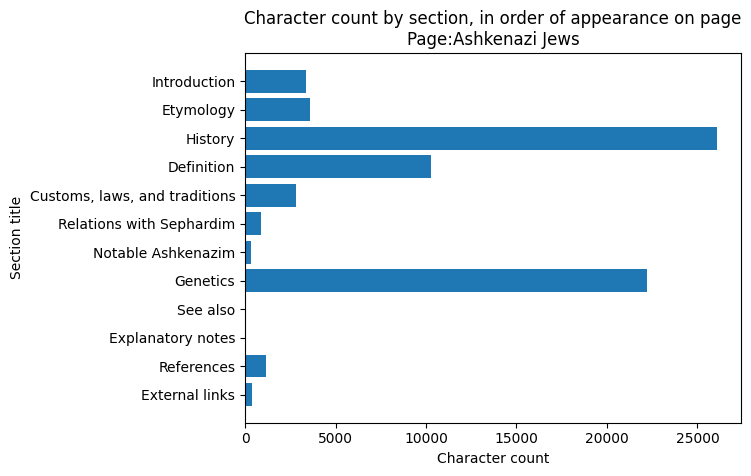

In [61]:
fig, ax = plt.subplots()

# Example data
ylabs = page_summary["section_title"].values
ypos = np.arange(len(ylabs))
xvals = page_summary["section_length"].values

ax.barh(ypos, xvals)
ax.set_yticks(ypos, labels=ylabs)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_ylabel("Section title")
ax.set_xlabel("Character count")
ax.set_title("Character count by section, in order of appearance on page\nPage:" + page_name.replace("_"," "))

#plt.savefig("figures/case_studies_characters_" + page_name + ".svg", dpi=600, bbox_inches="tight")

plt.show()

In [64]:
page_summary

,section_title,section_length,top_level_section,out_clicks,percent_length,percent_clicks
0,Introduction,3345,0,37720.0,0.047033,0.707003
1,Etymology,3611,1,3685.0,0.050773,0.069070
2,History,26102,2,5455.0,0.367008,0.102245
3,Definition,10291,3,436.0,0.144697,0.008172
4,"Customs, laws, and traditions",2804,4,239.0,0.039426,0.004480
5,Relations with Sephardim,877,5,1156.0,0.012331,0.021667
6,Notable Ashkenazim,321,6,2511.0,0.004513,0.047065
7,Genetics,22201,7,2150.0,0.312158,0.040298
8,See also,40,8,0.0,0.000562,0.000000
9,Explanatory notes,24,9,0.0,0.000337,0.000000


Text(0, 0.5, 'Clicks out')

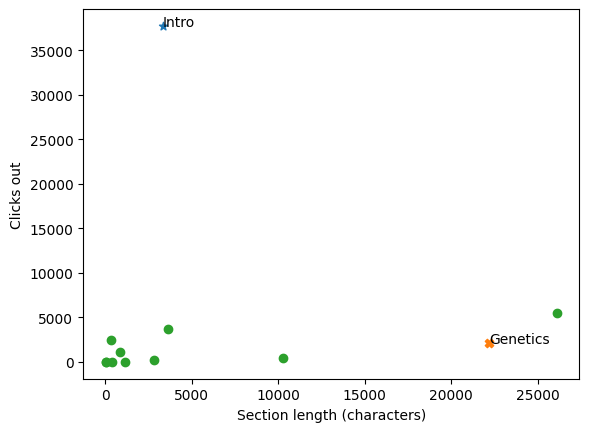

In [89]:
skip_sections = ["Introduction","Genetics"]

intro_xy = (
    page_summary[page_summary["section_title"]=="Introduction"]["section_length"].values[0],
    page_summary[page_summary["section_title"]=="Introduction"]["out_clicks"].values[0]
)

genetics_xy = (
    page_summary[page_summary["section_title"]=="Genetics"]["section_length"].values[0],
    page_summary[page_summary["section_title"]=="Genetics"]["out_clicks"].values[0]
)

# Bivariate plot of character count versus section length
plt.scatter(
    x = intro_xy[0],
    y = intro_xy[1],
    marker = "*"
)
plt.annotate(
    text = "Intro",
    xy = intro_xy
)
plt.scatter(
    x = genetics_xy[0],
    y = genetics_xy[1],
    marker = "X"
)
plt.annotate(
    text = "Genetics",
    xy = genetics_xy
)
plt.scatter(
    x = page_summary[~page_summary["section_title"].isin(skip_sections)]["section_length"],
    y = page_summary[~page_summary["section_title"].isin(skip_sections)]["out_clicks"]
)
plt.xlabel("Section length (characters)")
plt.ylabel("Clicks out")

# Historical revisions

Look for genetics sections in previous revisions.

In [21]:
pat_genetics = r'DNA|(?i:genet)|(?i:admix)|(?i:biobank)|(?i:genom)|(?i:chromosom)|(?i:autosom)|(?i:genotyp)|(?i:mitochon)|(?i:haplo)'

## Hereditarianism (and other stuff)

In [6]:
revision_contents_parquet_dir = ".../data/datasets/wikipedia/data/databases/parquet/revision_contents_processed"

### Ashkenazi Jews

In [3]:
page = "Ashkenazi_Jews"

revision_contents_path = os.path.join(revision_contents_parquet_dir, page + ".parquet")

contents_df = pd.read_parquet(revision_contents_path)

In [19]:
keyword = "IQ"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

In [20]:
# Last explicit mention of IQ
gen_url(contents_df[mask]["revision_id"].values[-1])

'https://en.wikipedia.org/wiki/index.php?oldid=1172125970'

In [21]:
# Last explicit mention of intelligence
keyword = "intelligen"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

In [22]:
# Last explicit mention of intelligence
gen_url(contents_df[mask]["revision_id"].values[-1])

'https://en.wikipedia.org/wiki/index.php?oldid=1172681072'

In [25]:
# Last explicit mention of CHH paper
keyword = "Cochran"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

In [26]:
# Last explicit mention of Cochran
gen_url(contents_df[mask]["revision_id"].values[-1])

'https://en.wikipedia.org/wiki/index.php?oldid=1172681072'

### Black people

In [7]:
page = "Black_people"

revision_contents_path = os.path.join(revision_contents_parquet_dir, page + ".parquet")

contents_df = pd.read_parquet(revision_contents_path)

In [92]:
keyword = "IQ"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

# All explicit mentions of IQ
# (WARNING: Last revision with IQ is vandalism with racial slurs)
for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

https://en.wikipedia.org/wiki/index.php?oldid=25145533
https://en.wikipedia.org/wiki/index.php?oldid=25145858
https://en.wikipedia.org/wiki/index.php?oldid=25245599
https://en.wikipedia.org/wiki/index.php?oldid=25245853
https://en.wikipedia.org/wiki/index.php?oldid=25245955
https://en.wikipedia.org/wiki/index.php?oldid=25342307
https://en.wikipedia.org/wiki/index.php?oldid=25342402
https://en.wikipedia.org/wiki/index.php?oldid=25342504
https://en.wikipedia.org/wiki/index.php?oldid=25368784
https://en.wikipedia.org/wiki/index.php?oldid=25369001
https://en.wikipedia.org/wiki/index.php?oldid=25374885
https://en.wikipedia.org/wiki/index.php?oldid=25470554
https://en.wikipedia.org/wiki/index.php?oldid=25603235
https://en.wikipedia.org/wiki/index.php?oldid=25604356
https://en.wikipedia.org/wiki/index.php?oldid=25622262
https://en.wikipedia.org/wiki/index.php?oldid=25690629
https://en.wikipedia.org/wiki/index.php?oldid=25691902
https://en.wikipedia.org/wiki/index.php?oldid=25691982
https://en

In [93]:
keyword = "intelligenc"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

# All explicit mentions of intelligence
for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

https://en.wikipedia.org/wiki/index.php?oldid=26506393
https://en.wikipedia.org/wiki/index.php?oldid=26506591
https://en.wikipedia.org/wiki/index.php?oldid=26507136
https://en.wikipedia.org/wiki/index.php?oldid=26507165
https://en.wikipedia.org/wiki/index.php?oldid=26507210
https://en.wikipedia.org/wiki/index.php?oldid=26507327
https://en.wikipedia.org/wiki/index.php?oldid=26507345
https://en.wikipedia.org/wiki/index.php?oldid=26507544
https://en.wikipedia.org/wiki/index.php?oldid=26507589
https://en.wikipedia.org/wiki/index.php?oldid=26508629
https://en.wikipedia.org/wiki/index.php?oldid=26603871
https://en.wikipedia.org/wiki/index.php?oldid=26619859
https://en.wikipedia.org/wiki/index.php?oldid=26683339
https://en.wikipedia.org/wiki/index.php?oldid=26686096
https://en.wikipedia.org/wiki/index.php?oldid=26806260
https://en.wikipedia.org/wiki/index.php?oldid=26806552
https://en.wikipedia.org/wiki/index.php?oldid=26945659
https://en.wikipedia.org/wiki/index.php?oldid=26949551
https://en

In [94]:
# All explicit mentions of Rushton
keyword = "Rushton"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

https://en.wikipedia.org/wiki/index.php?oldid=79539121
https://en.wikipedia.org/wiki/index.php?oldid=79543569
https://en.wikipedia.org/wiki/index.php?oldid=79543996
https://en.wikipedia.org/wiki/index.php?oldid=79545159
https://en.wikipedia.org/wiki/index.php?oldid=79546504
https://en.wikipedia.org/wiki/index.php?oldid=79548881
https://en.wikipedia.org/wiki/index.php?oldid=79549242
https://en.wikipedia.org/wiki/index.php?oldid=79558323
https://en.wikipedia.org/wiki/index.php?oldid=79563667
https://en.wikipedia.org/wiki/index.php?oldid=79619190
https://en.wikipedia.org/wiki/index.php?oldid=79619802
https://en.wikipedia.org/wiki/index.php?oldid=79619824
https://en.wikipedia.org/wiki/index.php?oldid=79620302
https://en.wikipedia.org/wiki/index.php?oldid=79620515
https://en.wikipedia.org/wiki/index.php?oldid=79620586
https://en.wikipedia.org/wiki/index.php?oldid=79621588
https://en.wikipedia.org/wiki/index.php?oldid=79622231
https://en.wikipedia.org/wiki/index.php?oldid=79622359
https://en

In [98]:
# All explicit mentions of Rushton's website
keyword = "http://www.harbornet.com/folks/theedrich/JP_Rushton/Race.htm"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

https://en.wikipedia.org/wiki/index.php?oldid=79539121
https://en.wikipedia.org/wiki/index.php?oldid=79543569
https://en.wikipedia.org/wiki/index.php?oldid=79543996
https://en.wikipedia.org/wiki/index.php?oldid=79545159
https://en.wikipedia.org/wiki/index.php?oldid=79546504
https://en.wikipedia.org/wiki/index.php?oldid=79548881
https://en.wikipedia.org/wiki/index.php?oldid=79549242
https://en.wikipedia.org/wiki/index.php?oldid=79558323
https://en.wikipedia.org/wiki/index.php?oldid=79563667
https://en.wikipedia.org/wiki/index.php?oldid=79619190
https://en.wikipedia.org/wiki/index.php?oldid=79619802
https://en.wikipedia.org/wiki/index.php?oldid=79619824
https://en.wikipedia.org/wiki/index.php?oldid=79620302
https://en.wikipedia.org/wiki/index.php?oldid=79620515
https://en.wikipedia.org/wiki/index.php?oldid=79620586
https://en.wikipedia.org/wiki/index.php?oldid=79621588
https://en.wikipedia.org/wiki/index.php?oldid=79622231
https://en.wikipedia.org/wiki/index.php?oldid=79622359
https://en

In [8]:
# All explicit mentions of Lynn
keyword = "Lynn"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

In [95]:
# All explicit mentions of Jensen
keyword = "Jensen"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

https://en.wikipedia.org/wiki/index.php?oldid=79896369
https://en.wikipedia.org/wiki/index.php?oldid=79896668
https://en.wikipedia.org/wiki/index.php?oldid=79898285
https://en.wikipedia.org/wiki/index.php?oldid=79911525
https://en.wikipedia.org/wiki/index.php?oldid=79911656
https://en.wikipedia.org/wiki/index.php?oldid=79911916
https://en.wikipedia.org/wiki/index.php?oldid=79912236
https://en.wikipedia.org/wiki/index.php?oldid=79912473
https://en.wikipedia.org/wiki/index.php?oldid=79912577
https://en.wikipedia.org/wiki/index.php?oldid=79915196
https://en.wikipedia.org/wiki/index.php?oldid=79915840
https://en.wikipedia.org/wiki/index.php?oldid=79916519
https://en.wikipedia.org/wiki/index.php?oldid=79916938
https://en.wikipedia.org/wiki/index.php?oldid=79917239
https://en.wikipedia.org/wiki/index.php?oldid=79919770
https://en.wikipedia.org/wiki/index.php?oldid=79924357
https://en.wikipedia.org/wiki/index.php?oldid=79924555
https://en.wikipedia.org/wiki/index.php?oldid=79928656
https://en

In [100]:
# All explicit mentions of Michael Levin
keyword = "Michael Levin"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

https://en.wikipedia.org/wiki/index.php?oldid=79543569
https://en.wikipedia.org/wiki/index.php?oldid=79543996
https://en.wikipedia.org/wiki/index.php?oldid=79545159
https://en.wikipedia.org/wiki/index.php?oldid=79546504
https://en.wikipedia.org/wiki/index.php?oldid=79548881
https://en.wikipedia.org/wiki/index.php?oldid=79549242
https://en.wikipedia.org/wiki/index.php?oldid=79558323
https://en.wikipedia.org/wiki/index.php?oldid=79563667
https://en.wikipedia.org/wiki/index.php?oldid=79619190
https://en.wikipedia.org/wiki/index.php?oldid=79619802
https://en.wikipedia.org/wiki/index.php?oldid=79619824
https://en.wikipedia.org/wiki/index.php?oldid=79620302
https://en.wikipedia.org/wiki/index.php?oldid=79620515
https://en.wikipedia.org/wiki/index.php?oldid=79620586
https://en.wikipedia.org/wiki/index.php?oldid=79621588
https://en.wikipedia.org/wiki/index.php?oldid=79622231
https://en.wikipedia.org/wiki/index.php?oldid=79622359
https://en.wikipedia.org/wiki/index.php?oldid=79622390
https://en

In [102]:
# "Biological definition"
keyword = "==Biological"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

https://en.wikipedia.org/wiki/index.php?oldid=79911525
https://en.wikipedia.org/wiki/index.php?oldid=79911656
https://en.wikipedia.org/wiki/index.php?oldid=79911916
https://en.wikipedia.org/wiki/index.php?oldid=79912236
https://en.wikipedia.org/wiki/index.php?oldid=79912473
https://en.wikipedia.org/wiki/index.php?oldid=79912577
https://en.wikipedia.org/wiki/index.php?oldid=79915196
https://en.wikipedia.org/wiki/index.php?oldid=79915840
https://en.wikipedia.org/wiki/index.php?oldid=79916519
https://en.wikipedia.org/wiki/index.php?oldid=79916938
https://en.wikipedia.org/wiki/index.php?oldid=79917239
https://en.wikipedia.org/wiki/index.php?oldid=79919770
https://en.wikipedia.org/wiki/index.php?oldid=79924357
https://en.wikipedia.org/wiki/index.php?oldid=79924555
https://en.wikipedia.org/wiki/index.php?oldid=79928656
https://en.wikipedia.org/wiki/index.php?oldid=79929188
https://en.wikipedia.org/wiki/index.php?oldid=79931119
https://en.wikipedia.org/wiki/index.php?oldid=80046721
https://en

In [73]:
# All explicit mentions of race and intelligence
for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

https://en.wikipedia.org/wiki/index.php?oldid=26506393
https://en.wikipedia.org/wiki/index.php?oldid=26506591
https://en.wikipedia.org/wiki/index.php?oldid=26507136
https://en.wikipedia.org/wiki/index.php?oldid=26507165
https://en.wikipedia.org/wiki/index.php?oldid=26507210
https://en.wikipedia.org/wiki/index.php?oldid=26507327
https://en.wikipedia.org/wiki/index.php?oldid=26507345
https://en.wikipedia.org/wiki/index.php?oldid=26507544
https://en.wikipedia.org/wiki/index.php?oldid=26507589
https://en.wikipedia.org/wiki/index.php?oldid=26508629
https://en.wikipedia.org/wiki/index.php?oldid=26603871
https://en.wikipedia.org/wiki/index.php?oldid=26619859
https://en.wikipedia.org/wiki/index.php?oldid=26683339
https://en.wikipedia.org/wiki/index.php?oldid=26686096
https://en.wikipedia.org/wiki/index.php?oldid=26806260
https://en.wikipedia.org/wiki/index.php?oldid=26806552
https://en.wikipedia.org/wiki/index.php?oldid=26945659
https://en.wikipedia.org/wiki/index.php?oldid=26949551
https://en

### White people

In [104]:
page = "White_people"

revision_contents_path = os.path.join(revision_contents_parquet_dir, page + ".parquet")

contents_df = pd.read_parquet(revision_contents_path)

In [107]:
keyword = "IQ"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

https://en.wikipedia.org/wiki/index.php?oldid=165161084


In [110]:
keyword = "Arthur Jensen"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

In [111]:
keyword = "Richard Lynn"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

In [113]:
keyword = "haplogroup"
mask = contents_df["markup"].str.contains(keyword, na=False, regex=False)

for v in contents_df[mask]["revision_id"]:
    print(gen_url(v))

https://en.wikipedia.org/wiki/index.php?oldid=47746357
https://en.wikipedia.org/wiki/index.php?oldid=47746700
https://en.wikipedia.org/wiki/index.php?oldid=47746976
https://en.wikipedia.org/wiki/index.php?oldid=47774863
https://en.wikipedia.org/wiki/index.php?oldid=47778579
https://en.wikipedia.org/wiki/index.php?oldid=47778595
https://en.wikipedia.org/wiki/index.php?oldid=47803929
https://en.wikipedia.org/wiki/index.php?oldid=47808050
https://en.wikipedia.org/wiki/index.php?oldid=47808400
https://en.wikipedia.org/wiki/index.php?oldid=47808707
https://en.wikipedia.org/wiki/index.php?oldid=47808878
https://en.wikipedia.org/wiki/index.php?oldid=47871739
https://en.wikipedia.org/wiki/index.php?oldid=47893244
https://en.wikipedia.org/wiki/index.php?oldid=47930292
https://en.wikipedia.org/wiki/index.php?oldid=47954786
https://en.wikipedia.org/wiki/index.php?oldid=47959361
https://en.wikipedia.org/wiki/index.php?oldid=47965614
https://en.wikipedia.org/wiki/index.php?oldid=47977049
https://en